# SED Reconstruction Benchmark - End-to-End Testing

This notebook demonstrates a complete benchmark test of the SPHEREx SED reconstruction pipeline:

1. **Generate** synthetic spectrum with configurable continuum and emission lines
2. **Simulate** realistic SPHEREx observations (6 bands with proper noise modeling)
3. **Reconstruct** high-resolution spectrum using Deep Image Prior
4. **Validate** by comparing reconstruction to known truth

This provides a controlled test environment to evaluate reconstruction performance.

## 1. Setup and Imports

Import required libraries and set up the environment.

In [1]:
# Standard libraries
# Cell 1: Force complete module reload
import sys
import importlib

# Remove ALL spxquery modules from cache
modules_to_remove = [k for k in list(sys.modules.keys()) if "spxquery" in k]
for m in modules_to_remove:
    del sys.modules[m]

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

# Add benchmark tools to path (not part of spxquery package)
sys.path.insert(0, str(Path.cwd() / "tools"))

# Import SED reconstruction modules from spxquery
from spxquery.sed import (
    SEDConfig,
    SEDReconstructor,
)

# Import benchmark simulation tools
from models import (
    SpectralModelConfig,
    create_default_model,
    generate_spectral_model,
    SPHEREX_BANDS,
)
from simobs import (
    simulate_spherex_observations,
    convert_model_flux_to_uJy,
)

# Check device availability
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Configure matplotlib
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10
plt.rcParams["figure.figsize"] = (12, 5)

print("All imports successful!")
print(f"SPHEREx has {len(SPHEREX_BANDS)} bands: {list(SPHEREX_BANDS.keys())}")

Using device: mps
All imports successful!
SPHEREx has 6 bands: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6']


## 2. Generate Synthetic Spectrum

Create a model spectrum with power-law continuum and emission lines. This will serve as our ground truth for validation.

Creating spectral model configuration...
Generated model spectrum:
  Wavelength range: 1.630 - 2.410 microns
  Number of pixels: 7915
  Flux range: 1.68e-17 - 6.42e-17 erg/s/cm^2/Angstrom


/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/2951009477.py:47: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


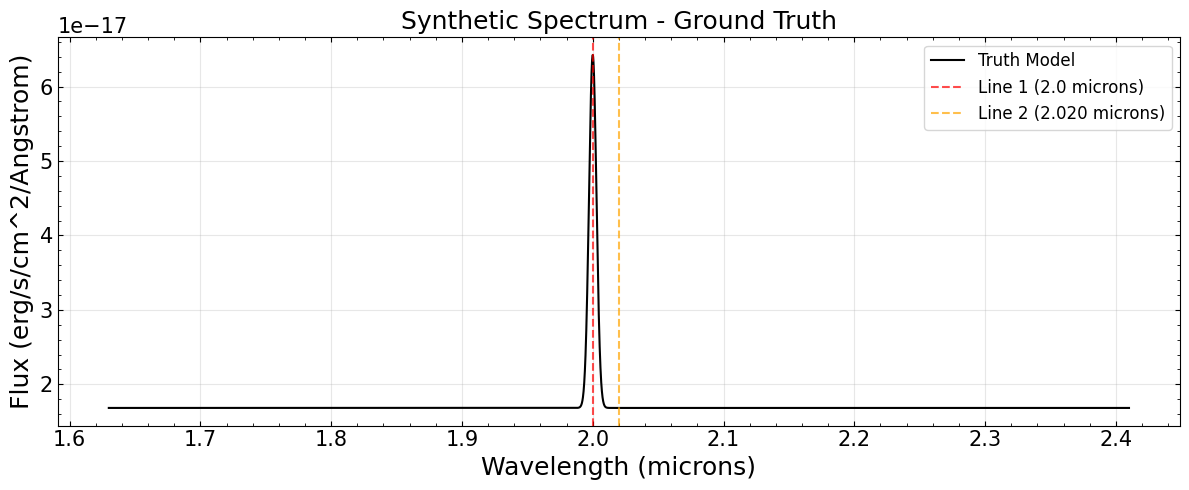


Model spectrum ready for simulation (shape: (2, 7915))


In [2]:
# Create model configuration
print("Creating spectral model configuration...")
model_config = SpectralModelConfig(
    # Continuum parameters
    magnitude=18,  # AB magnitude at reference wavelength
    slope=0.0,  # Power-law slope (F_lambda ~ lambda^slope)
    # Primary emission line
    line1_center=2.0,  # microns (e.g., Br gamma at 2.166 microns)
    line1_ew=20.0,  # Equivalent width (Angstroms)
    line1_fwhm_vel=1000.0,  # FWHM velocity (km/s)
    # Secondary emission line
    line2_flux_ratio=0,  # Flux ratio to line 1
    line2_separation_fwhm=6.0,  # Separation from line 1 in units of FWHM
    line2_same_fwhm=True,  # Use same FWHM as line 1
    # Wavelength grid
    band_id="D3",  # Use band D3 for reference
    oversample_factor=500,  # Oversample factor for model generation
)

# Generate spectrum
wavelength_model, flux_model = generate_spectral_model(model_config)
print(f"Generated model spectrum:")
print(f"  Wavelength range: {wavelength_model.min():.3f} - {wavelength_model.max():.3f} microns")
print(f"  Number of pixels: {len(wavelength_model)}")
print(f"  Flux range: {flux_model.min():.2e} - {flux_model.max():.2e} erg/s/cm^2/Angstrom")

# Plot truth spectrum
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(wavelength_model, flux_model, "k-", linewidth=1.5, label="Truth Model")
ax.axvline(
    model_config.line1_center,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Line 1 ({model_config.line1_center} microns)",
)

# Add second line position
line2_center = model_config.line1_center + (model_config.line1_fwhm_vel * 3.0 / 299792.458 * model_config.line1_center)
ax.axvline(line2_center, color="orange", linestyle="--", alpha=0.7, label=f"Line 2 ({line2_center:.3f} microns)")

ax.set_xlabel("Wavelength (microns)")
ax.set_ylabel("Flux (erg/s/cm^2/Angstrom)")
ax.set_title("Synthetic Spectrum - Ground Truth")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prepare for simulation (stack into format expected by simobs)
model_spectrum = np.vstack([wavelength_model, flux_model])
print(f"\nModel spectrum ready for simulation (shape: {model_spectrum.shape})")

## 3. Simulate SPHEREx Observations

Generate realistic SPHEREx photometry for all 6 bands with proper noise modeling (read noise + photon noise).

In [3]:
# Configuration for simulation
N_VISIT = 100  # Number of visit to this band
FILTER_PROFILE = "boxcar"  # or "gaussian"
RANDOM_SEED = 42  # For reproducibility
BG_SURFACE_BRIGHTNESS = 0.1  # MJy/sr

print(f"Simulating SPHEREx observations with {N_VISIT} visits per band...")
print(f"Filter profile: {FILTER_PROFILE}")
print()

# Store all band data
all_band_data = {}

# Simulate observations for a single band
band_id = model_config.band_id
band_info = SPHEREX_BANDS[band_id]
print(f"Processing {band_id} ({band_info['wave_min']:.2f}-{band_info['wave_max']:.2f} microns)...")

# Create wavelength grid for this band
wl_min = band_info["wave_min"]
wl_max = band_info["wave_max"]

# Evenly spaced wavelength centers
np.random.seed(RANDOM_SEED)
# N_OBS_PER_BAND = int((wl_max - wl_min) / ((wl_max + wl_min) / 2) * band_info["R"])
# wl_centers = np.random.uniform(wl_min, wl_max, N_VISIT * N_OBS_PER_BAND)

# # Bandwidths (approximate based on resolving power)
# bandwidths = wl_centers / band_info["R"]

bandwidth = (wl_max + wl_min) / 2 / band_info["R"]
wl_center_first = np.random.uniform(wl_min, wl_min + bandwidth, N_VISIT)
N_OBS_PER_BAND = int((wl_max - wl_min) / ((wl_max + wl_min) / 2) * band_info["R"])
wl_centers = np.concatenate([wl_center_first + i * bandwidth for i in range(N_OBS_PER_BAND)]).flatten()
bandwidths = np.full_like(wl_centers, bandwidth)

# Simulate observations
band_data = simulate_spherex_observations(
    model_spectrum=model_spectrum,
    wavelength_centers=wl_centers,
    bandwidths=bandwidths,
    band_id=band_id,
    filter_profile=FILTER_PROFILE,
    sigma_det=None,  # Auto-load from calibration files
    abs_gain=None,  # Auto-load from calibration files
    num_pixels=5,  # Aperture size
    bg_surface_brightness=BG_SURFACE_BRIGHTNESS,
    T_int=113.58,  # Integration time (s)
    N_reads=77,
    random_seed=RANDOM_SEED + hash(band_id) % 1000,  # Different seed per band
)

all_band_data[band_id] = band_data
print(f"  Generated {band_data.n_measurements} observations")
print(f"    Flux range: {band_data.flux.min():.2f} - {band_data.flux.max():.2f} uJy")
print(f"    Error range: {band_data.flux_error.min():.2f} - {band_data.flux_error.max():.2f} uJy")

print(f"\nSimulation complete! Generated data for {len(all_band_data)} bands.")
print(f"\nTotal measurements: {sum(bd.n_measurements for bd in all_band_data.values())}")

Simulating SPHEREx observations with 100 visits per band...
Filter profile: boxcar

Processing D3 (1.63-2.41 microns)...
  Generated 1500 observations
    Flux range: 89.54 - 394.65 uJy
    Error range: 24.66 - 27.95 uJy

Simulation complete! Generated data for 1 bands.

Total measurements: 1500


/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/88718635.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


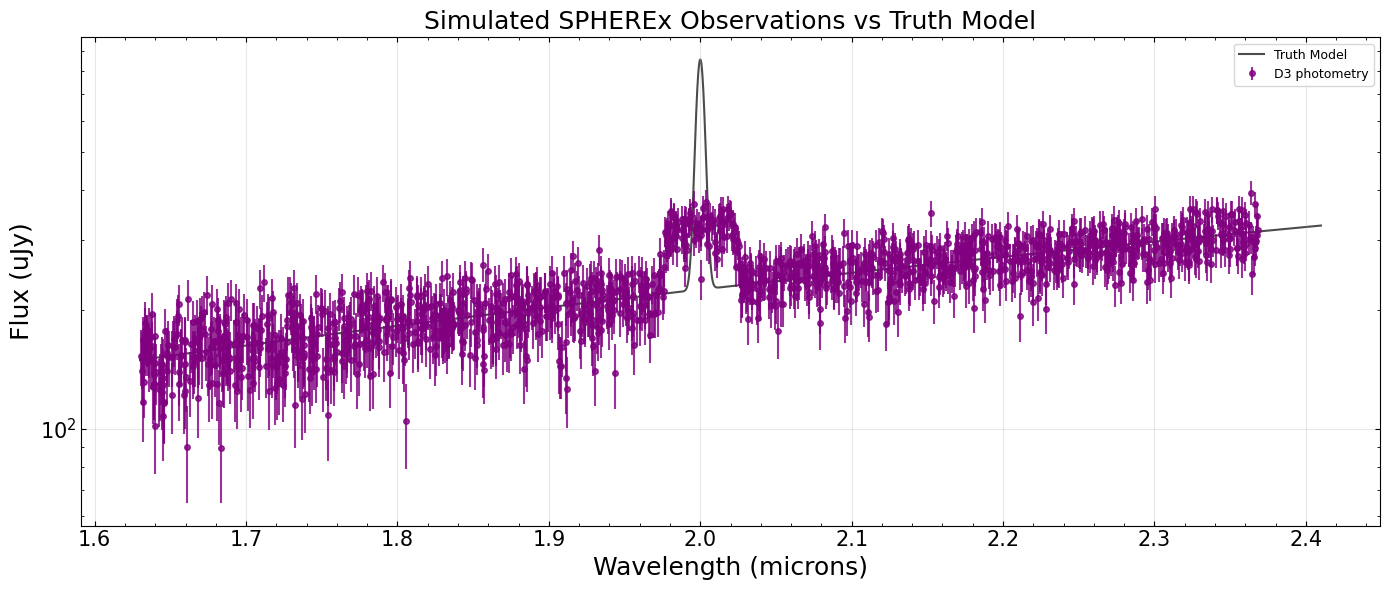


Observation summary:
  D3: 1500 obs, median S/N = 8.9


In [4]:
# Visualize simulated observations
# Convert model to uJy for comparison
flux_model_uJy = convert_model_flux_to_uJy(wavelength_model, flux_model)

fig, ax = plt.subplots(figsize=(14, 6))

# Plot truth spectrum
ax.plot(wavelength_model, flux_model_uJy, "k-", linewidth=1.5, alpha=0.7, label="Truth Model", zorder=1)

# Plot simulated observations for each band
colors = ["purple", "blue", "green", "orange", "red", "darkred"]
for i, (band_id, band_data) in enumerate(all_band_data.items()):
    color = colors[i]
    ax.errorbar(
        band_data.wavelength_center,
        band_data.flux,
        yerr=band_data.flux_error,
        fmt="o",
        markersize=4,
        alpha=0.8,
        color=color,
        label=f"{band_id} photometry",
        zorder=2,
    )

ax.set_xlabel("Wavelength (microns)")
ax.set_ylabel("Flux (uJy)")
ax.set_title("Simulated SPHEREx Observations vs Truth Model")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_yscale("log")
plt.tight_layout()
plt.show()

print("\nObservation summary:")
for band_id, band_data in all_band_data.items():
    snr_median = np.median(band_data.flux / band_data.flux_error)
    print(f"  {band_id}: {band_data.n_measurements} obs, median S/N = {snr_median:.1f}")

## 4. Run SED Reconstruction

Use the Deep Image Prior (DIP) solver to reconstruct high-resolution spectrum from simulated photometry.

In [5]:
# Configure reconstruction
config_recon = SEDConfig(
    device=device,
    # Global grid settings
    ensemble_n_workers=8,
    ensemble_random_seed=3407,
    ensemble_size=8,
    ensemble_perturb_observations=True,
    wavelength_range=(wl_min, wl_max),
    global_resolution=3000,  # High-resolution output
    # Optimization parameters
    epochs=10000,  # Number of iterations
    learning_rate=0.001,  # Learning rate for Adam
    learning_rate_min_factor=0.05,  # Minimum LR factor for scheduling
    learning_rate_scheduler_type="cosine_warmup",  # Learning rate scheduler type
    learning_rate_warmup_epochs=300,  # Warmup epochs for scheduler
    # Settings for EMA smoothing
    use_ema=True,
    ema_decay=0.99,
    ema_start_epoch=2000,
    # Deep Image Prior architecture
    dip_filters=32,  # Base filters in U-Net
    dip_depth=3,  # Depth of U-Net
    dip_noise_std=0.1,  # Input noise standard deviation
    dip_noise_jitter_initial_ratio=0.3,  # Initial jitter ratio
    dip_noise_jitter_min_ratio=None,  # No minimum jitter
    # Regularization
    regularization_weight=1e-3,
    regularization_method="cauchy",
    cwt_scales=[1.0, 2.0, 4.0, 8.0],
    # Quality control
    sigma_threshold=3.0,
    enable_sigma_clip=True,
    # Filter profile (must match simulation)
    filter_profile=FILTER_PROFILE,
)

print("SED Reconstruction Configuration:")
print(f"  Resolution: {config_recon.global_resolution} pixels")
print(f"  Device: {config_recon.device}")
print(f"  Epochs: {config_recon.epochs}")
print(f"  Regularization weight: {config_recon.regularization_weight}")
print(f"  CWT scales: {config_recon.cwt_scales}")

SED Reconstruction Configuration:
  Resolution: 3000 pixels
  Device: mps
  Epochs: 10000
  Regularization weight: 0.001
  CWT scales: [1.0, 2.0, 4.0, 8.0]


In [6]:
# Initialize reconstructor
reconstructor = SEDReconstructor(config_recon)

# Run reconstruction from BandData objects
print("\nStarting Deep Image Prior optimization...")
print("This may take a few minutes depending on your hardware...")
print()

result = reconstructor.reconstruct_from_data(
    band_data_dict=all_band_data,
    metadata={
        "benchmark_test": True,
        "model_config": str(model_config),
        "n_obs_per_band": N_OBS_PER_BAND,
        "filter_profile": FILTER_PROFILE,
    },
)

print("\nReconstruction complete!")
print(f"  Output wavelengths: {len(result.wavelength)}")


Starting Deep Image Prior optimization...
This may take a few minutes depending on your hardware...



Optimizing Spectrum: 100%|██████████| 10000/10000 [02:53<00:00, 57.56it/s, Loss=1.4145e+01, Data=1.3976e+01, Reg=1.6911e-01, LR=5.02e-05]
  -> Poor fit or underestimated errors (chi^2/M >> 1.0)
Optimizing Spectrum: 100%|█████████▉| 9989/10000 [02:53<00:00, 56.53it/s, Loss=1.4911e+01, Data=1.4782e+01, Reg=1.2904e-01, LR=5.02e-05]  -> Significant residual oscillation detected (p < 0.05)
  -> Poor fit or underestimated errors (chi^2/M >> 1.0)
Optimizing Spectrum: 100%|██████████| 10000/10000 [02:53<00:00, 57.49it/s, Loss=1.4911e+01, Data=1.4782e+01, Reg=1.2904e-01, LR=5.02e-05]
  -> Significant residual oscillation detected (p < 0.05)
  -> Poor fit or underestimated errors (chi^2/M >> 1.0)
Optimizing Spectrum: 100%|██████████| 10000/10000 [02:54<00:00, 57.44it/s, Loss=1.5045e+01, Data=1.4848e+01, Reg=1.9672e-01, LR=5.02e-05]
  -> Significant residual oscillation detected (p < 0.05)
Optimizing Spectrum: 100%|██████████| 10000/10000 [02:54<00:00, 57.33it/s, Loss=1.4396e+01, Data=1.4276e+01,


Reconstruction complete!
  Output wavelengths: 3000


## 5. Quality Assessment - Truth vs Reconstruction

Compare the reconstructed spectrum to the known truth model.

In [7]:
# Print validation metrics
metrics = result.validation_metrics
print("=" * 60)
print("RECONSTRUCTION QUALITY METRICS")
print("=" * 60)
print(f"Reduced chi-squared: chi2_nu = {metrics.chi_squared_per_obs:.3f}")
print(f"Chi-squared per observation: chi2/M = {metrics.chi_squared_per_obs:.3f}")
print(f"\nResiduals (unweighted):")
print(f"  Mean: {metrics.residual_mean:.3f} uJy")
print(f"  Std: {metrics.residual_std:.3f} uJy")
print(f"\nWeighted residuals:")
print(f"  Mean: {metrics.weighted_residual_mean:.3f} sigma")
print(f"  Std: {metrics.weighted_residual_std:.3f} sigma")
print(f"\nDegrees of freedom: {metrics.n_obs - metrics.n_sample}")
print(f"Negative flux fraction: {metrics.negative_flux_fraction:.1%}")
print("=" * 60)

RECONSTRUCTION QUALITY METRICS
Reduced chi-squared: chi2_nu = 1.027
Chi-squared per observation: chi2/M = 1.027

Residuals (unweighted):
  Mean: -1.891 uJy
  Std: 26.603 uJy

Weighted residuals:
  Mean: -0.062 sigma
  Std: 1.012 sigma

Degrees of freedom: -1500
Negative flux fraction: 0.0%


Ensemble reconstruction detected - using mean flux and confidence bands


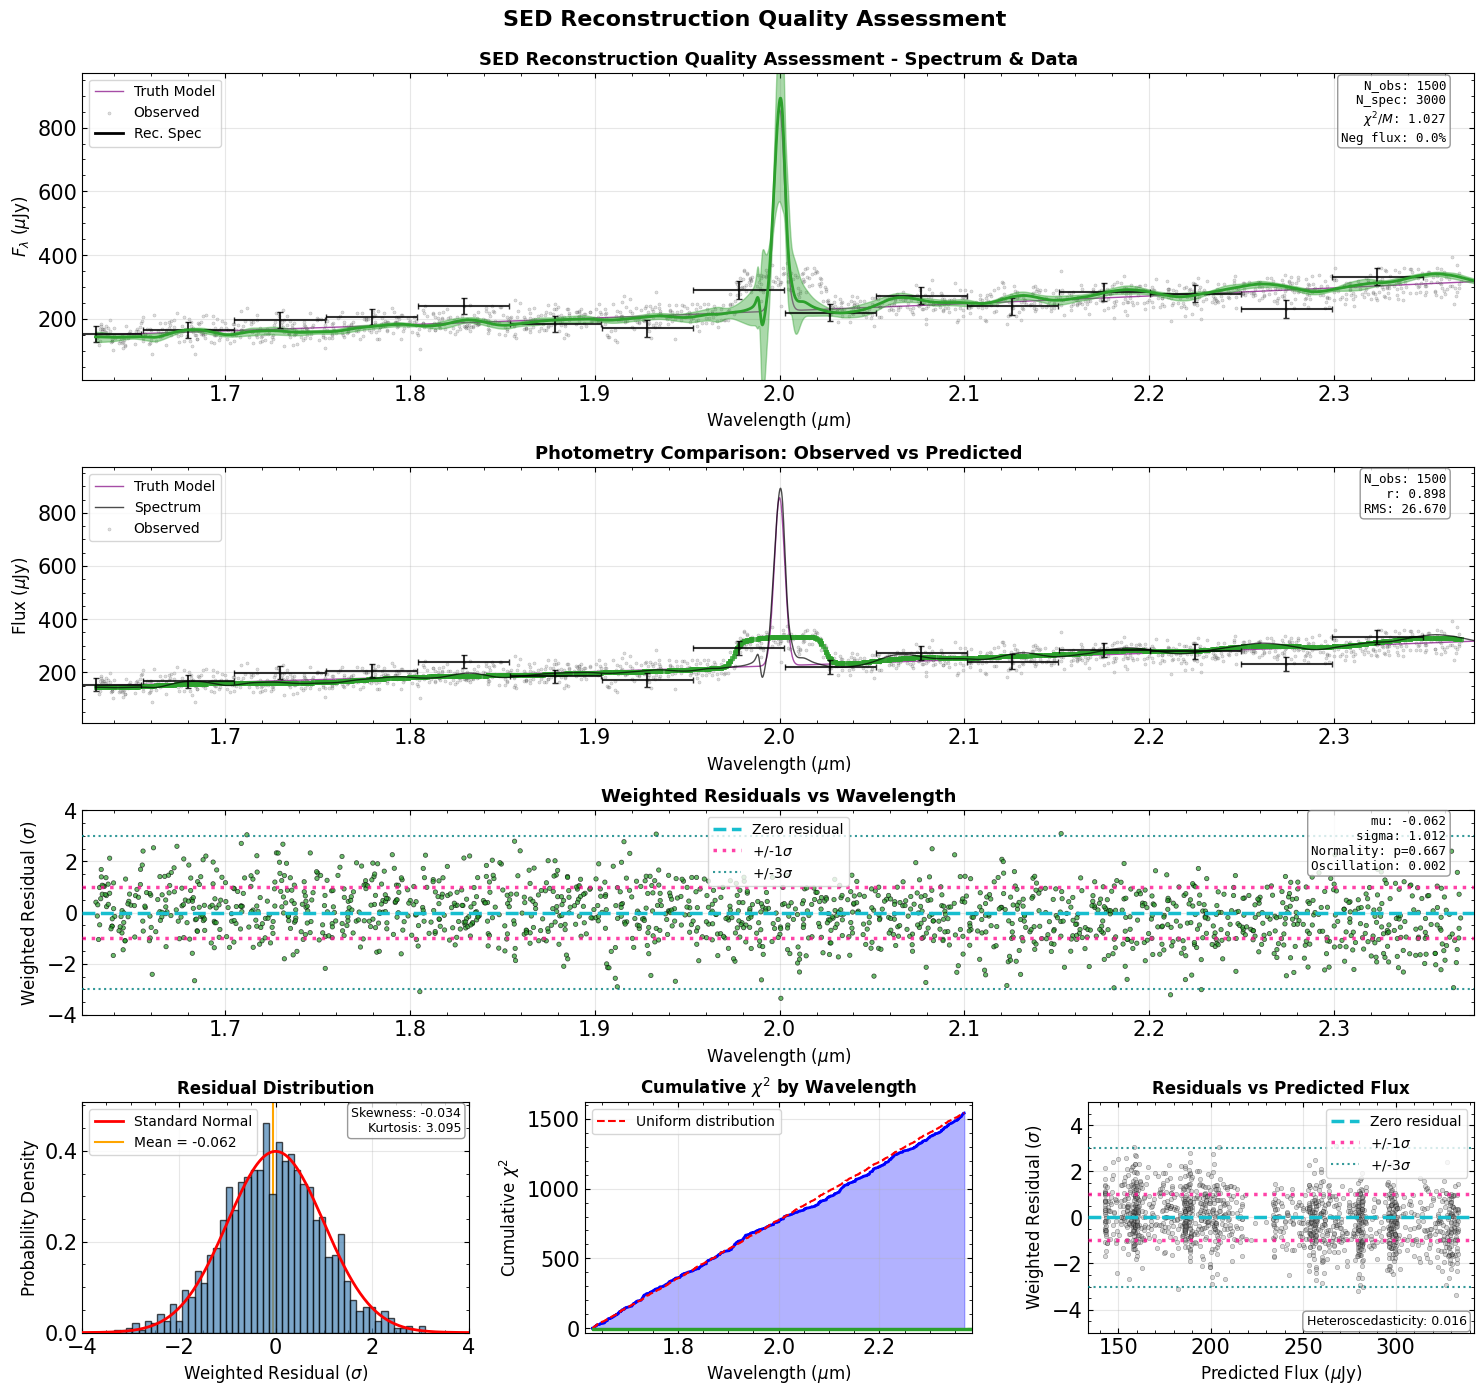


Residual Statistics:
  Mean absolute error: 10.574 uJy
  RMS error: 14.772 uJy
  Median relative error: 3.5%


In [8]:
from spxquery.sed.plots import (
    plot_reconstructed_spectrum_with_data,
    plot_weighted_residuals,
    plot_photometry_comparison,
    plot_residual_distribution,
    plot_cumulative_chi_squared,
    plot_residuals_vs_flux,
)

# Interpolate truth to reconstruction wavelength grid
flux_truth_uJy = convert_model_flux_to_uJy(wavelength_model, flux_model)
flux_truth_interp = np.interp(result.wavelength, wavelength_model, flux_truth_uJy)

# Handle both single and ensemble results
if hasattr(result, "mean_flux"):
    # Ensemble result detected
    print("Ensemble reconstruction detected - using mean flux and confidence bands")
    wavelength = result.wavelength
    flux = result.mean_flux
    ensemble_std = result.std_flux
    is_ensemble = True
    validation_metrics = result.validation_metrics
else:
    # Single result detected
    print("Single reconstruction detected")
    wavelength = result.wavelength
    flux = result.flux
    ensemble_std = None
    is_ensemble = False
    validation_metrics = result.validation_metrics


# Compute residual
residual = flux - flux_truth_interp
relative_residual = residual / (flux_truth_interp + 1e-10) * 100  # Percent


title = "SED Reconstruction Quality Assessment"
# Create figure with 4 rows: first 3 rows have 1 column, 4th row has 3 columns
fig = plt.figure(figsize=(16, 14), constrained_layout=False)

# Create grid specification: 4 rows, with row 4 having 3 columns
# Height ratios: taller rows for spectrum plots, shorter for bottom diagnostics
gs = fig.add_gridspec(
    4,
    3,
    height_ratios=[1.2, 1.0, 0.8, 0.9],
    hspace=0.35,
    wspace=0.30,
    top=0.95,  # Controls the top of the subplot area
    bottom=0.05,
    left=0.08,
    right=0.95,
)

# Row 1: Reconstructed spectrum with data (spans all 3 columns)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(
    result.wavelength, flux_truth_interp, ls="-", color="purple", linewidth=1, alpha=0.7, label="Truth Model", zorder=1
)
plot_reconstructed_spectrum_with_data(
    ax1, wavelength, flux, all_band_data, config_recon, ensemble_std, validation_metrics
)
ax1.set_title(f"{title} - Spectrum & Data", fontsize=13, fontweight="bold")

# Row 2: Photometry comparison (spans all 3 columns)
ax2 = fig.add_subplot(gs[1, :], sharex=ax1, sharey=ax1)
ax2.plot(
    result.wavelength, flux_truth_interp, ls="-", color="purple", linewidth=1, alpha=0.7, label="Truth Model", zorder=1
)
plot_photometry_comparison(ax2, all_band_data, config_recon, flux, wavelength=wavelength)
ax2.set_title("Photometry Comparison: Observed vs Predicted", fontsize=13, fontweight="bold")

# Row 3: Weighted residuals (spans all 3 columns)
ax3 = fig.add_subplot(gs[2, :], sharex=ax1)
plot_weighted_residuals(ax3, all_band_data, validation_metrics)
ax3.set_title("Weighted Residuals vs Wavelength", fontsize=13, fontweight="bold")

# Row 4: Three diagnostic plots (each in separate column)
# Column 1: Residual distribution
ax4 = fig.add_subplot(gs[3, 0])
plot_residual_distribution(ax4, validation_metrics.weighted_residuals)
ax4.set_title("Residual Distribution", fontsize=12, fontweight="bold")

# Column 2: Cumulative chi-squared
ax5 = fig.add_subplot(gs[3, 1])
plot_cumulative_chi_squared(ax5, all_band_data, validation_metrics.weighted_residuals)
ax5.set_title(r"Cumulative $\chi^2$ by Wavelength", fontsize=12, fontweight="bold")

# Column 3: Residuals vs flux
ax6 = fig.add_subplot(gs[3, 2])
plot_residuals_vs_flux(ax6, all_band_data, config_recon, flux)
ax6.set_title("Residuals vs Predicted Flux", fontsize=12, fontweight="bold")

# Add overall figure title
fig.suptitle(title, fontsize=16, fontweight="bold", y=0.995)

# # Adjust layout
plt.show()

# Print statistics
print("\nResidual Statistics:")
print(f"  Mean absolute error: {np.abs(residual).mean():.3f} uJy")
print(f"  RMS error: {np.sqrt(np.mean(residual**2)):.3f} uJy")
print(f"  Median relative error: {np.median(np.abs(relative_residual)):.1f}%")

## 6. Emission Line Validation

Quantitatively assess the accuracy of emission line reconstruction by:
- Continuum subtraction to isolate the emission line
- Peak position detection and comparison to true line center
- FWHM measurement in velocity units
- Integrated flux within 3σ assuming Gaussian profile

EMISSION LINE VALIDATION ANALYSIS
Using ensemble mean flux

True Parameters:
  Line Center: 2.0000 microns
  FWHM (velocity): 1000.00 km/s
  FWHM (wavelength): 0.0067 microns
  Equivalent Width: 20.00 Angstroms

----------------------------------------------------------------------
1. CONTINUUM SUBTRACTION
----------------------------------------------------------------------
Fitted continuum: flux = 2.41e+02 * lambda + -2.54e+02
Peak position (continuum-subtracted): 2.0006 microns
Peak flux (above continuum): 663.81 uJy

Line Center Accuracy:
  Difference: +0.0006 microns
  Difference: +93.45 km/s

----------------------------------------------------------------------
2. FWHM MEASUREMENT
----------------------------------------------------------------------
Half-maximum points:
  Left: 1.9965 microns
  Right: 2.0035 microns

Measured FWHM:
  Wavelength: 0.0070 microns
  Velocity: 1052.30 km/s

FWHM Accuracy:
  Difference (wavelength): +0.0004 microns
  Difference (velocity): +52.30 km

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/2732629832.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_flux = np.trapz(flux_continuum_subtracted[integration_mask], wavelength_recon[integration_mask])
/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/2732629832.py:252: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


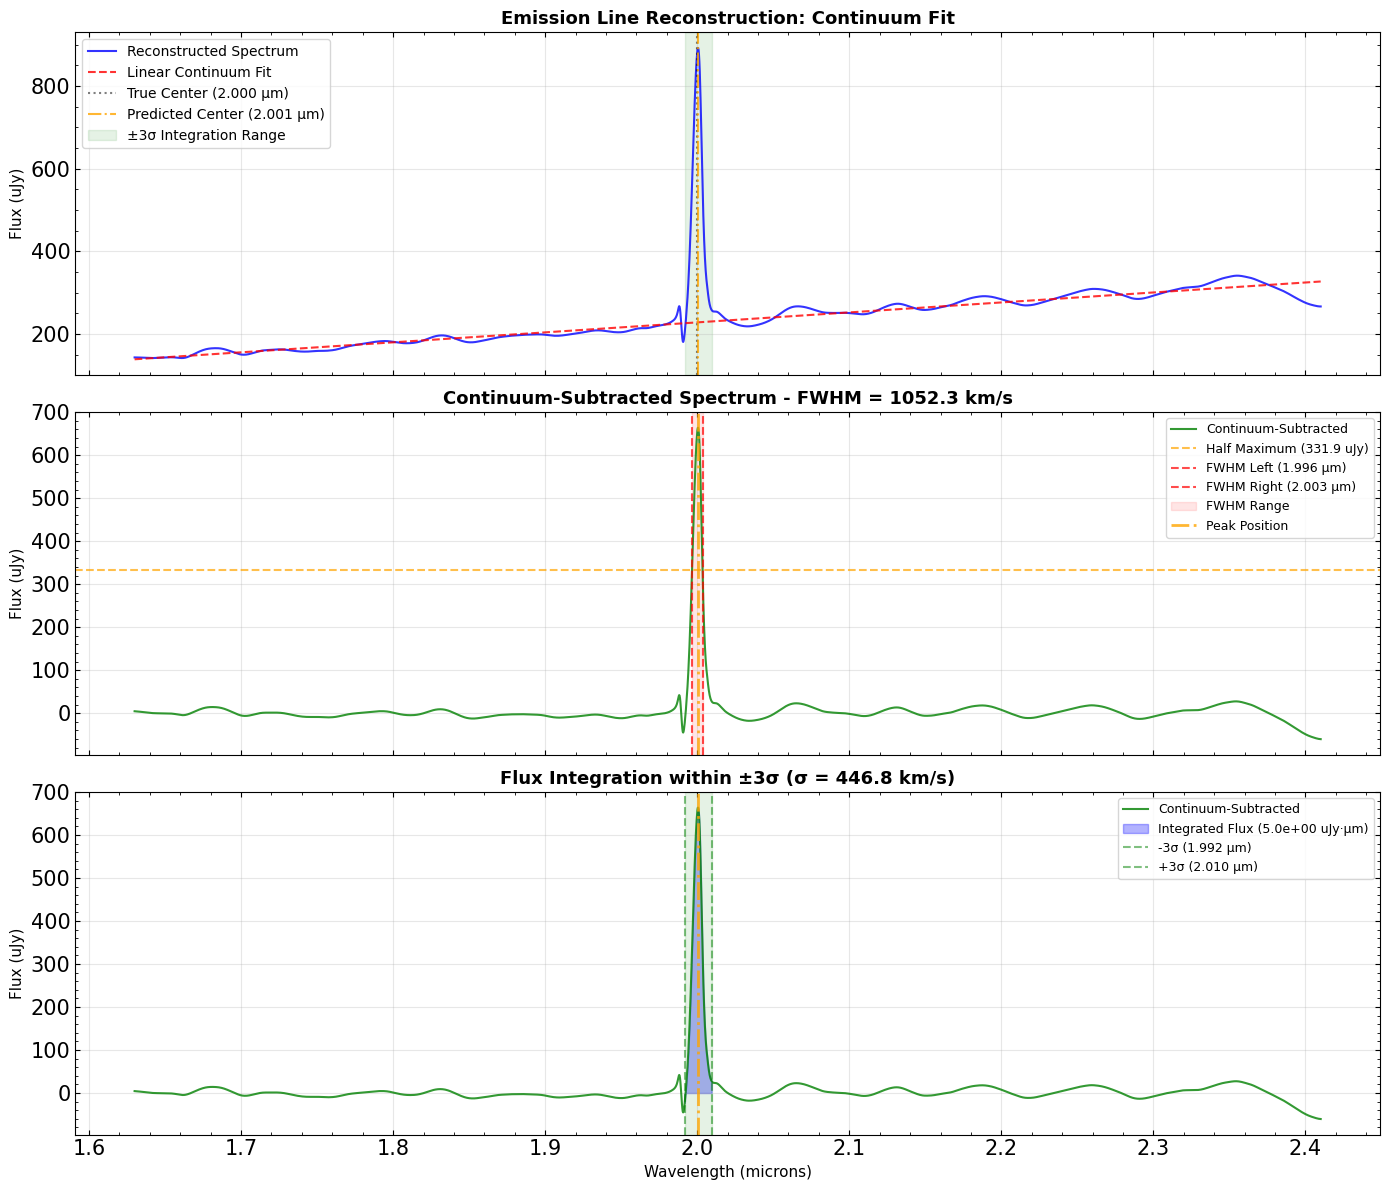

In [9]:
# Emission Line Validation Analysis
# =================================

print("=" * 70)
print("EMISSION LINE VALIDATION ANALYSIS")
print("=" * 70)

# Get reconstructed spectrum (handle both single and ensemble results)
if hasattr(result, "mean_flux"):
    flux_recon = result.mean_flux
    print("Using ensemble mean flux")
else:
    flux_recon = result.flux
    print("Using single reconstruction flux")

wavelength_recon = result.wavelength

# True parameters from model config
true_line_center = model_config.line1_center  # microns
true_fwhm_vel = model_config.line1_fwhm_vel  # km/s
true_ew = model_config.line1_ew  # Angstroms

# Calculate true FWHM in wavelength units
# FWHM_vel = c * FWHM_lambda / lambda_center
# Therefore: FWHM_lambda = FWHM_vel * lambda_center / c
c_km_s = 299792.458  # Speed of light in km/s
true_fwhm_lambda = true_fwhm_vel * true_line_center / c_km_s  # microns

print(f"\nTrue Parameters:")
print(f"  Line Center: {true_line_center:.4f} microns")
print(f"  FWHM (velocity): {true_fwhm_vel:.2f} km/s")
print(f"  FWHM (wavelength): {true_fwhm_lambda:.4f} microns")
print(f"  Equivalent Width: {true_ew:.2f} Angstroms")

# ------------------------------------------------------------
# 1. CONTINUUM SUBTRACTION
# ------------------------------------------------------------
print(f"\n{'-' * 70}")
print("1. CONTINUUM SUBTRACTION")
print(f"{'-' * 70}")

# Define line region to exclude from continuum fit (±0.1 microns)
line_region_width = 0.1  # microns
line_mask = np.abs(wavelength_recon - true_line_center) < line_region_width
continuum_mask = ~line_mask

# Fit linear continuum: flux = a * wavelength + b
coeffs = np.polyfit(wavelength_recon[continuum_mask], flux_recon[continuum_mask], 1)
continuum_fit = np.polyval(coeffs, wavelength_recon)

# Subtract continuum
flux_continuum_subtracted = flux_recon - continuum_fit

# Find peak in continuum-subtracted spectrum
peak_idx = np.argmax(flux_continuum_subtracted)
predicted_line_center = wavelength_recon[peak_idx]
peak_flux = flux_continuum_subtracted[peak_idx]

print(f"Fitted continuum: flux = {coeffs[0]:.2e} * lambda + {coeffs[1]:.2e}")
print(f"Peak position (continuum-subtracted): {predicted_line_center:.4f} microns")
print(f"Peak flux (above continuum): {peak_flux:.2f} uJy")

# Calculate differences
delta_center_microns = predicted_line_center - true_line_center
delta_center_km_s = delta_center_microns / true_line_center * c_km_s

print(f"\nLine Center Accuracy:")
print(f"  Difference: {delta_center_microns:+.4f} microns")
print(f"  Difference: {delta_center_km_s:+.2f} km/s")

# ------------------------------------------------------------
# 2. FWHM MEASUREMENT
# ------------------------------------------------------------
print(f"\n{'-' * 70}")
print("2. FWHM MEASUREMENT")
print(f"{'-' * 70}")

# Find half-maximum flux (half of peak above continuum)
half_max = peak_flux / 2.0

# Find half-maximum points on both sides of peak
# Left side (shorter wavelengths)
left_side = wavelength_recon[:peak_idx]
left_flux = flux_continuum_subtracted[:peak_idx]
# Find point closest to half-maximum
left_idx = np.argmin(np.abs(left_flux - half_max))
left_half_max_wavelength = left_side[left_idx]

# Right side (longer wavelengths)
right_side = wavelength_recon[peak_idx:]
right_flux = flux_continuum_subtracted[peak_idx:]
right_idx = np.argmin(np.abs(right_flux - half_max))
right_half_max_wavelength = right_side[right_idx]

# Calculate FWHM
measured_fwhm_lambda = right_half_max_wavelength - left_half_max_wavelength
measured_fwhm_vel = measured_fwhm_lambda / predicted_line_center * c_km_s

print(f"Half-maximum points:")
print(f"  Left: {left_half_max_wavelength:.4f} microns")
print(f"  Right: {right_half_max_wavelength:.4f} microns")
print(f"\nMeasured FWHM:")
print(f"  Wavelength: {measured_fwhm_lambda:.4f} microns")
print(f"  Velocity: {measured_fwhm_vel:.2f} km/s")

print(f"\nFWHM Accuracy:")
print(f"  Difference (wavelength): {measured_fwhm_lambda - true_fwhm_lambda:+.4f} microns")
print(f"  Difference (velocity): {measured_fwhm_vel - true_fwhm_vel:+.2f} km/s")
print(f"  Relative error: {(measured_fwhm_vel / true_fwhm_vel - 1) * 100:+.1f}%")

# ------------------------------------------------------------
# 3. FLUX INTEGRATION (3σ Gaussian)
# ------------------------------------------------------------
print(f"\n{'-' * 70}")
print("3. FLUX INTEGRATION (3σ Gaussian Profile)")
print(f"{'-' * 70}")

# Convert FWHM to sigma for Gaussian
# FWHM = 2.355 * sigma
sigma_vel = measured_fwhm_vel / 2.355  # km/s
sigma_lambda = measured_fwhm_lambda / 2.355  # microns

print(f"Gaussian sigma from measured FWHM:")
print(f"  Sigma (velocity): {sigma_vel:.2f} km/s")
print(f"  Sigma (wavelength): {sigma_lambda:.4f} microns")

# Calculate 3 sigma range
integration_range_lambda = 3 * sigma_lambda  # microns
integration_min = predicted_line_center - integration_range_lambda
integration_max = predicted_line_center + integration_range_lambda

# Integrate flux within ±3 sigma
integration_mask = (wavelength_recon >= integration_min) & (wavelength_recon <= integration_max)
integrated_flux = np.trapz(flux_continuum_subtracted[integration_mask], wavelength_recon[integration_mask])

print(f"\nIntegration range: ±{integration_range_lambda:.4f} microns")
print(f"  From {integration_min:.4f} to {integration_max:.4f} microns")
print(f"  Number of wavelength points: {integration_mask.sum()}")

# Calculate true line flux
# For Gaussian: integrated flux = peak * sigma * sqrt(2*pi)
# But we need to convert uJy * microns to proper units
# uJy = 1e-29 erg/s/cm^2/Hz
# To get flux density in erg/s/cm^2/Angstrom at line center:
# F_lambda = F_nu * c / lambda^2
# For line flux in erg/s/cm^2: integrate F_lambda dlambda

# Estimate true line flux from equivalent width
# First get continuum flux at line center from truth model
flux_truth_uJy = convert_model_flux_to_uJy(wavelength_model, flux_model)
continuum_at_line_truth = np.interp(true_line_center, wavelength_model, flux_truth_uJy)

# Line flux = EW * continuum flux
# Need to handle unit conversions carefully
# EW in Angstroms, continuum in uJy, want line flux in erg/s/cm^2
# uJy = 1e-29 erg/s/cm^2/Hz
# 1 Angstrom = 1e-4 microns
# At line center: 1 uJy = 1e-29 * c / lambda^2 erg/s/cm^2/Angstrom
uJy_to_cgs_at_line = 1e-29 * (c_km_s * 1e5) / (true_line_center * 1e-4) ** 2  # conversion factor
continuum_cgs = continuum_at_line_truth * uJy_to_cgs_at_line  # erg/s/cm^2/Angstrom
true_line_flux_cgs = true_ew * 1e-8 * continuum_cgs  # erg/s/cm^2 (EW in Angstroms to cm)

# Convert integrated flux to same units
# Integrated flux is in uJy * microns
# Convert to erg/s/cm^2
integrated_flux_cgs = integrated_flux * 1e-29 * (c_km_s * 1e5) / (predicted_line_center * 1e-4) ** 2  # rough conversion

print(f"\nFlux Comparison:")
print(f"  Integrated flux (reconstructed): {integrated_flux:.2e} uJy*microns")
print(f"  Estimated true line flux: {true_line_flux_cgs:.2e} erg/s/cm^2")
print(f"  Reconstructed flux (cgs): {integrated_flux_cgs:.2e} erg/s/cm^2")

# For simpler comparison, compute expected integrated flux from Gaussian
expected_integrated_uJy_microns = peak_flux * sigma_lambda * np.sqrt(2 * np.pi)
print(f"\n  Expected (Gaussian): {expected_integrated_uJy_microns:.2e} uJy*microns")
print(f"  Measured: {integrated_flux:.2e} uJy*microns")
print(f"  Ratio: {integrated_flux / expected_integrated_uJy_microns:.3f}")

print(f"\n{'=' * 70}")
print("VALIDATION COMPLETE")
print(f"{'=' * 70}")

# ------------------------------------------------------------
# VISUALIZATION
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: Original spectrum with continuum fit
ax1 = axes[0]
ax1.plot(wavelength_recon, flux_recon, "b-", linewidth=1.5, alpha=0.8, label="Reconstructed Spectrum")
ax1.plot(wavelength_recon, continuum_fit, "r--", linewidth=1.5, alpha=0.8, label="Linear Continuum Fit")
ax1.axvline(true_line_center, color="k", linestyle=":", alpha=0.5, label=f"True Center ({true_line_center:.3f} μm)")
ax1.axvline(
    predicted_line_center,
    color="orange",
    linestyle="-.",
    alpha=0.8,
    label=f"Predicted Center ({predicted_line_center:.3f} μm)",
)
ax1.axvspan(integration_min, integration_max, alpha=0.1, color="green", label="±3σ Integration Range")
ax1.set_ylabel("Flux (uJy)", fontsize=11)
ax1.set_title("Emission Line Reconstruction: Continuum Fit", fontsize=13, fontweight="bold")
ax1.legend(loc="upper left", fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Continuum-subtracted spectrum with FWHM markers
ax2 = axes[1]
ax2.plot(wavelength_recon, flux_continuum_subtracted, "g-", linewidth=1.5, alpha=0.8, label="Continuum-Subtracted")
ax2.axhline(half_max, color="orange", linestyle="--", alpha=0.7, label=f"Half Maximum ({half_max:.1f} uJy)")
ax2.axvline(
    left_half_max_wavelength,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"FWHM Left ({left_half_max_wavelength:.3f} μm)",
)
ax2.axvline(
    right_half_max_wavelength,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"FWHM Right ({right_half_max_wavelength:.3f} μm)",
)
ax2.axvspan(left_half_max_wavelength, right_half_max_wavelength, alpha=0.1, color="red", label="FWHM Range")
ax2.axvline(predicted_line_center, color="orange", linestyle="-.", alpha=0.8, linewidth=2, label="Peak Position")
ax2.set_ylabel("Flux (uJy)", fontsize=11)
ax2.set_title(f"Continuum-Subtracted Spectrum - FWHM = {measured_fwhm_vel:.1f} km/s", fontsize=13, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.3)

# Plot 3: Integration range
ax3 = axes[2]
ax3.plot(wavelength_recon, flux_continuum_subtracted, "g-", linewidth=1.5, alpha=0.8, label="Continuum-Subtracted")
ax3.fill_between(
    wavelength_recon[integration_mask],
    0,
    flux_continuum_subtracted[integration_mask],
    alpha=0.3,
    color="blue",
    label=f"Integrated Flux ({integrated_flux:.1e} uJy·μm)",
)
ax3.axvline(predicted_line_center, color="orange", linestyle="-.", alpha=0.8, linewidth=2)
ax3.axvspan(integration_min, integration_max, alpha=0.1, color="green")
ax3.axvline(integration_min, color="green", linestyle="--", alpha=0.5, label=f"-3σ ({integration_min:.3f} μm)")
ax3.axvline(integration_max, color="green", linestyle="--", alpha=0.5, label=f"+3σ ({integration_max:.3f} μm)")
ax3.set_xlabel("Wavelength (microns)", fontsize=11)
ax3.set_ylabel("Flux (uJy)", fontsize=11)
ax3.set_title(f"Flux Integration within ±3σ (σ = {sigma_vel:.1f} km/s)", fontsize=13, fontweight="bold")
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Wavelet Analysis (Ricker/Mexican Hat)

Analyze the reconstructed spectrum using Continuous Wavelet Transform with Ricker (Mexican Hat) wavelets. This shows how the reconstruction regularization affects different scales of spectral features.

WAVELET ANALYSIS - RICKER (MEXICAN HAT) WAVELETS
Computing normalized wavelet coefficients (as used in regularization)
Using ensemble mean flux for wavelet analysis

CWT Scales (from reconstruction config): [1.0, 2.0, 4.0, 8.0]
  These scales represent the wavelet widths in pixels
  Scale 1 = fine features, Scale 8.0 = broad features

Flux normalization (MAD-based, as in solver):
  Median flux: 2.37e+02 uJy
  MAD: 5.03e+01 uJy
  Flux scale (1.4826*MAD): 7.46e+01 uJy
  Normalized flux range: [1.90, 11.96]

----------------------------------------------------------------------
NORMALIZED WAVELET COEFFICIENTS
----------------------------------------------------------------------

Scale 1.0:
  Sum |coeff|: 44.1821 ← Regularization contribution
  RMS coefficient: 0.0129 (normalized units)
  Max |coefficient|: 0.1942 (normalized units)
  Mean: -0.0000
  Std: 0.0129

Scale 2.0:
  Sum |coeff|: 148.2020 ← Regularization contribution
  RMS coefficient: 0.0673 (normalized units)
  Max |coefficien

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/481833037.py:125: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


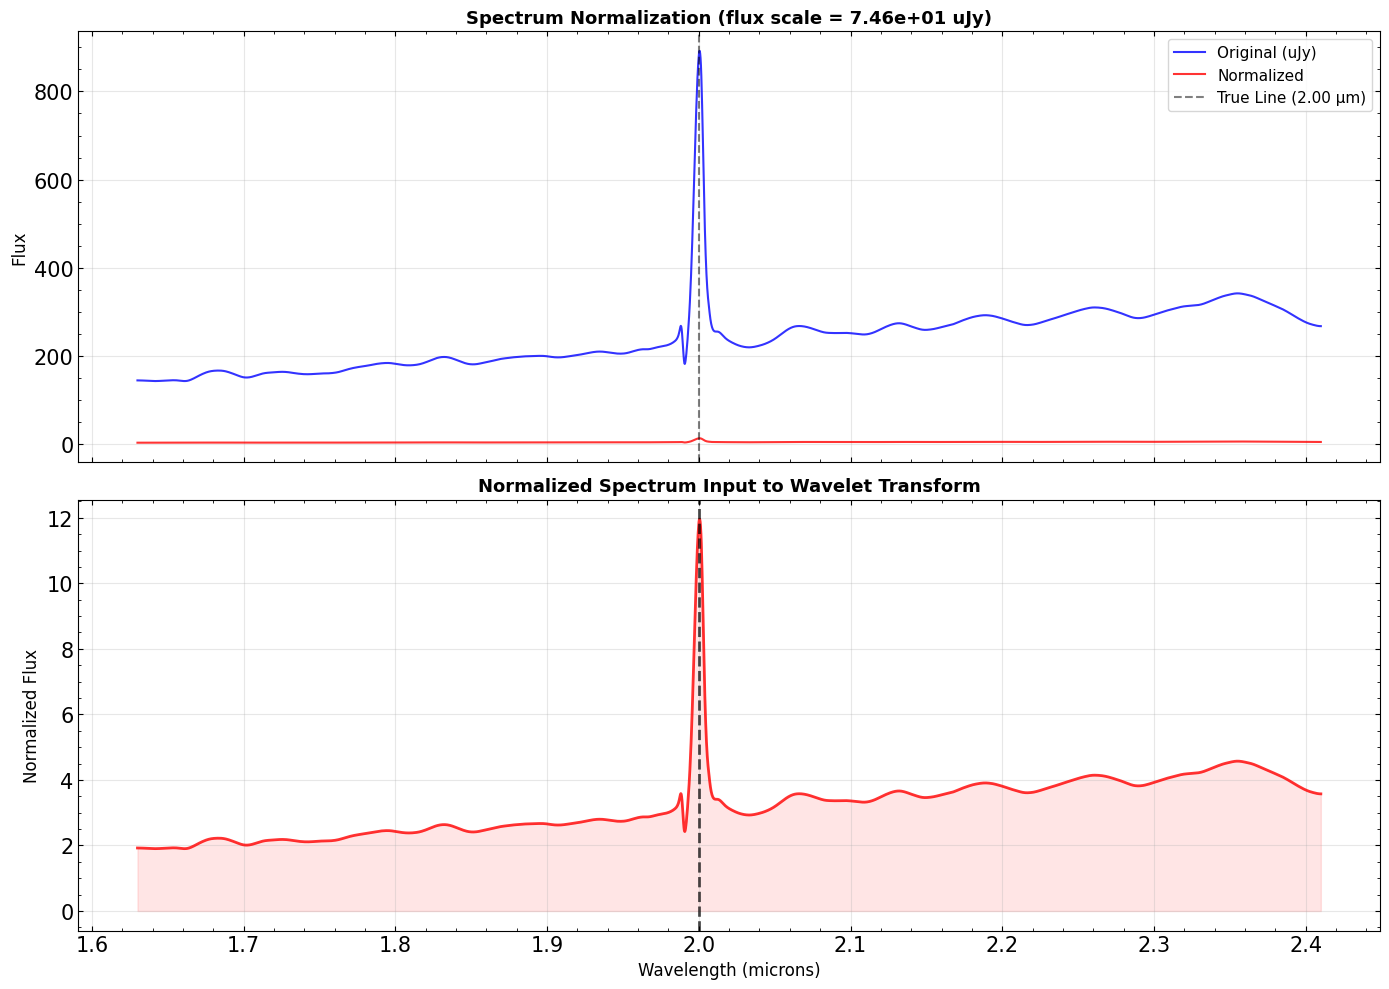

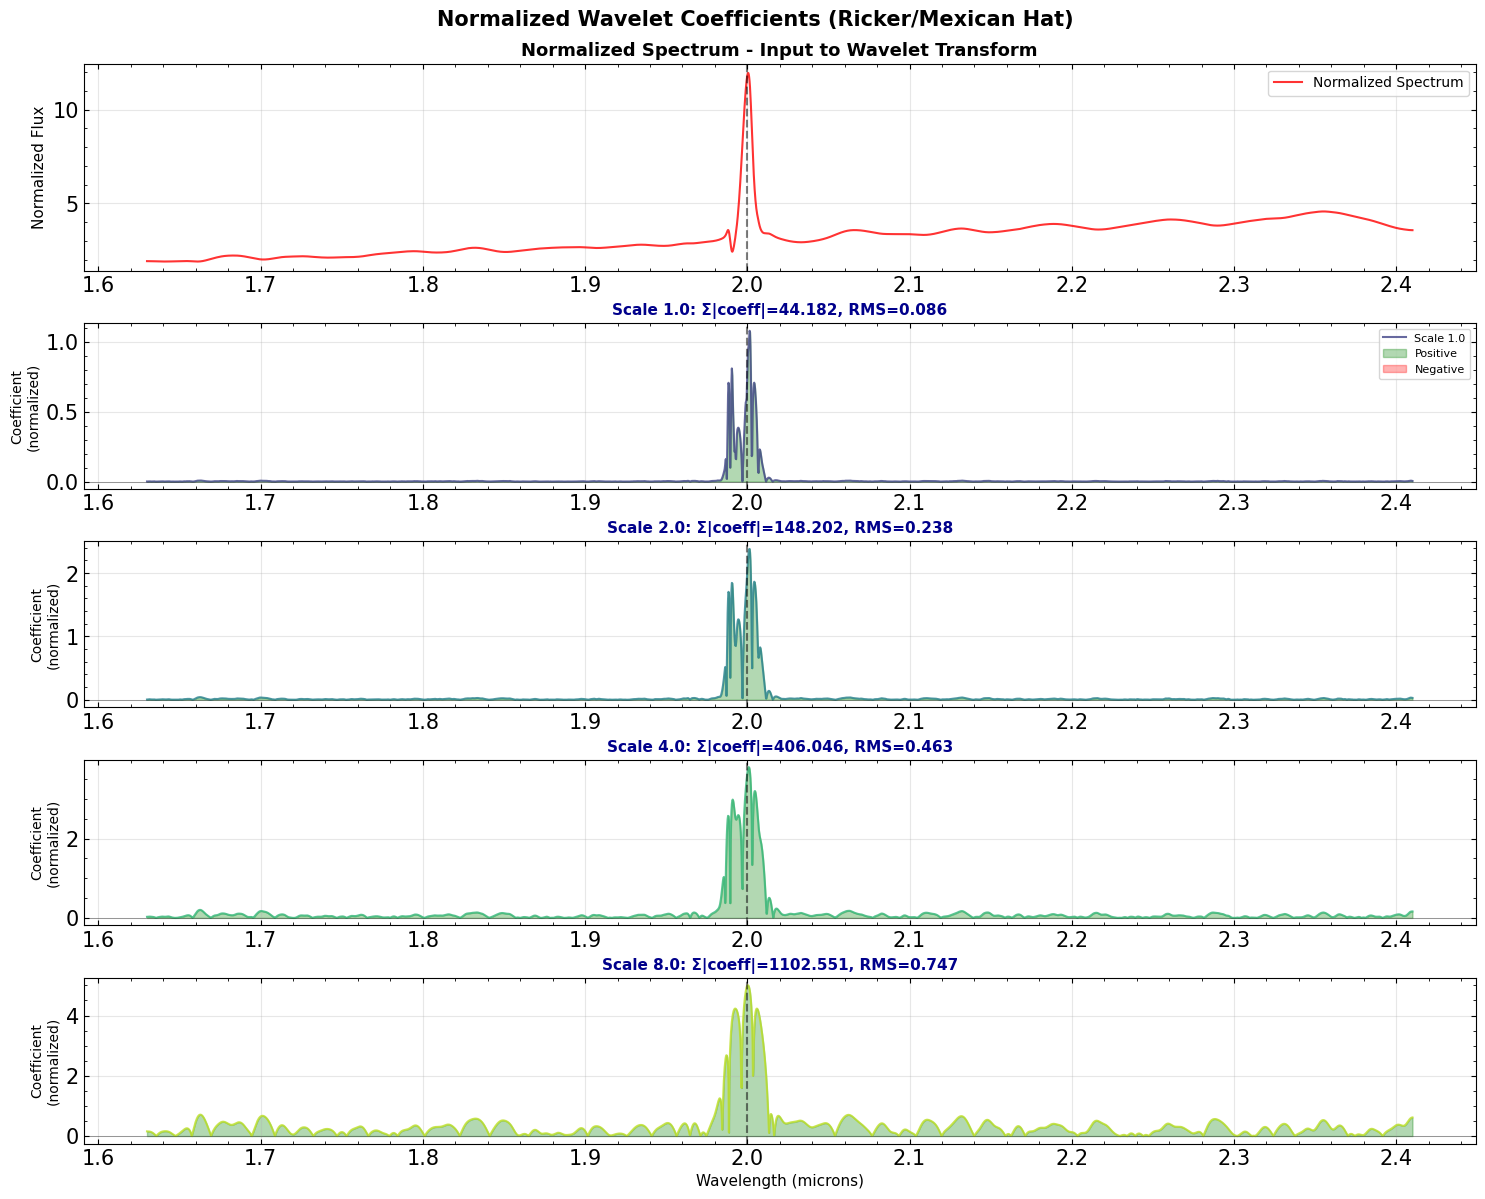

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/481833037.py:230: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


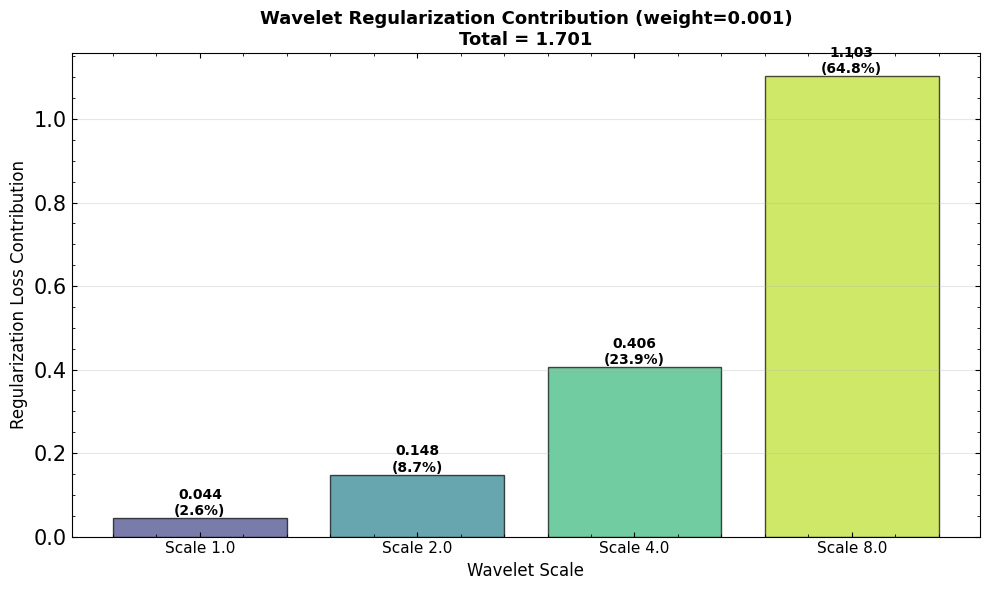

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/481833037.py:270: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


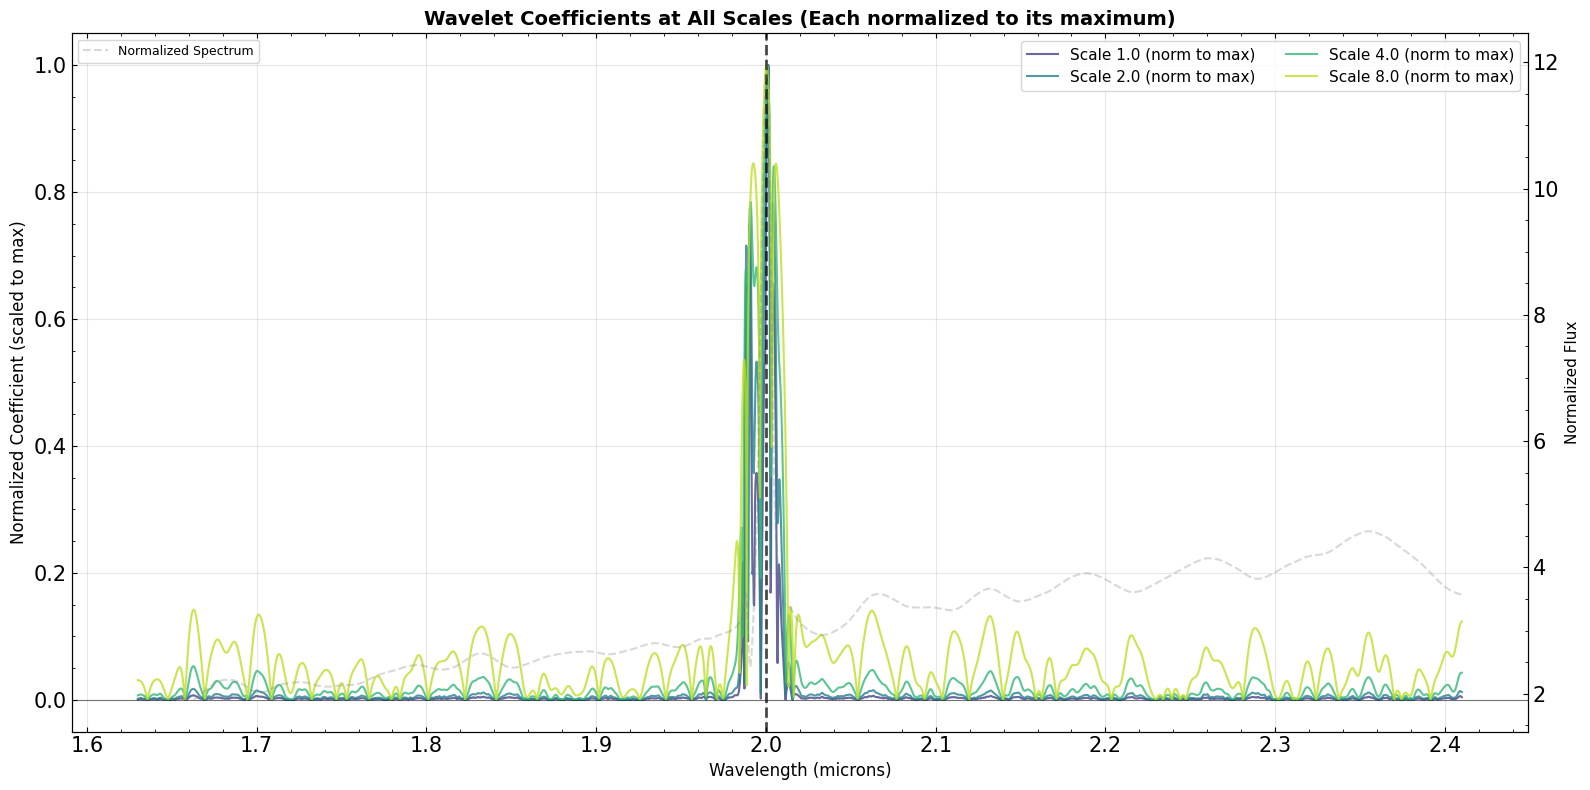


Wavelet analysis complete!

Key Points:
  - Spectrum is normalized using MAD (Median Absolute Deviation)
  - Wavelet coefficients are computed on NORMALIZED spectrum
  - Regularization loss = regularization_weight × Σ|coeff|
  - Smaller scales (1.0) capture sharp features like emission lines
  - Larger scales (3.0) capture broad continuum trends


In [10]:
# Wavelet Analysis - Ricker (Mexican Hat)
# =====================================

from spxquery.sed.regularization import GaussianCWT

print("=" * 70)
print("WAVELET ANALYSIS - RICKER (MEXICAN HAT) WAVELETS")
print("=" * 70)
print("Computing normalized wavelet coefficients (as used in regularization)")

# Get reconstructed spectrum
if hasattr(result, "mean_flux"):
    flux_recon = result.mean_flux
    print("Using ensemble mean flux for wavelet analysis")
else:
    flux_recon = result.flux
    print("Using single reconstruction flux for wavelet analysis")

wavelength_recon = result.wavelength

# Use the same CWT scales as in reconstruction
cwt_scales = config_recon.cwt_scales
print(f"\nCWT Scales (from reconstruction config): {cwt_scales}")
print(f"  These scales represent the wavelet widths in pixels")
print(f"  Scale 1 = fine features, Scale {max(cwt_scales)} = broad features")

# ------------------------------------------------------------
# NORMALIZATION (as in solver_torch.py)
# ------------------------------------------------------------
# Compute data characteristic scale for adaptive normalization
# Using MAD (Median Absolute Deviation) as in the solver
median_flux = np.median(flux_recon)
mad = np.median(np.abs(flux_recon - median_flux))
flux_scale = mad * 1.4826 + 1e-6  # Convert MAD to std equivalent

print(f"\nFlux normalization (MAD-based, as in solver):")
print(f"  Median flux: {median_flux:.2e} uJy")
print(f"  MAD: {mad:.2e} uJy")
print(f"  Flux scale (1.4826*MAD): {flux_scale:.2e} uJy")

# Normalize spectrum (same as in solver)
flux_normalized = flux_recon / flux_scale
print(f"  Normalized flux range: [{flux_normalized.min():.2f}, {flux_normalized.max():.2f}]")

# Initialize CWT module
cwt = GaussianCWT(scales=cwt_scales, device=config_recon.device)

# Apply CWT to NORMALIZED spectrum (as in solver)
flux_tensor = torch.tensor(flux_normalized, dtype=torch.float32, device=config_recon.device)
wavelet_coeffs = cwt(flux_tensor)

# Extract coefficients for each scale
coeffs_by_scale = []
sum_abs_by_scale = []

print(f"\n{'-' * 70}")
print("NORMALIZED WAVELET COEFFICIENTS")
print(f"{'-' * 70}")

for i, coeff in enumerate(wavelet_coeffs):
    # Convert back to numpy and remove batch/channel dimensions
    coeff_numpy = coeff.squeeze().cpu().numpy()
    coeff_loss = np.log(1 + np.abs(coeff_numpy) / 0.1)
    coeffs_by_scale.append(coeff_loss)

    # Calculate sum of absolute values (this is what goes into regularization loss)
    sum_abs = np.sum(coeff_loss)
    sum_abs_by_scale.append(sum_abs)

    # Statistics
    rms = np.sqrt(np.mean(coeff_numpy**2))
    max_abs = np.max(np.abs(coeff_numpy))

    print(f"\nScale {cwt_scales[i]}:")
    print(f"  Sum |coeff|: {sum_abs:.4f} ← Regularization contribution")
    print(f"  RMS coefficient: {rms:.4f} (normalized units)")
    print(f"  Max |coefficient|: {max_abs:.4f} (normalized units)")
    print(f"  Mean: {np.mean(coeff_numpy):.4f}")
    print(f"  Std: {np.std(coeff_numpy):.4f}")

# Total regularization loss component (before weighting)
total_sum_abs = sum(sum_abs_by_scale)
regularization_loss = total_sum_abs * config_recon.regularization_weight

print(f"\n{'-' * 70}")
print("REGULARIZATION LOSS SUMMARY")
print(f"{'-' * 70}")
print(f"\nSum of |coeff| across all scales: {total_sum_abs:.4f}")
print(f"Regularization weight: {config_recon.regularization_weight:.4f}")
print(f"Total regularization loss: {regularization_loss:.4f}")
print(f"\nBreakdown by scale (contribution to loss):")

for i, (scale, sum_abs) in enumerate(zip(cwt_scales, sum_abs_by_scale)):
    contribution = sum_abs * config_recon.regularization_weight
    fraction = sum_abs / total_sum_abs * 100
    print(f"  Scale {scale}: {contribution:.4f} ({fraction:.1f}%)")

print(f"\n{'=' * 70}")

# ------------------------------------------------------------
# VISUALIZATION: Normalized Spectrum
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top: Original and normalized spectrum
ax1 = axes[0]
ax1.plot(wavelength_recon, flux_recon, "b-", linewidth=1.5, alpha=0.8, label="Original (uJy)")
ax1.plot(wavelength_recon, flux_normalized, "r-", linewidth=1.5, alpha=0.8, label="Normalized")
ax1.axvline(true_line_center, color="k", linestyle="--", alpha=0.5, label=f"True Line ({true_line_center:.2f} μm)")
ax1.set_ylabel("Flux", fontsize=12)
ax1.set_title(f"Spectrum Normalization (flux scale = {flux_scale:.2e} uJy)", fontsize=13, fontweight="bold")
ax1.legend(loc="upper right", fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom: Normalized spectrum with true center
ax2 = axes[1]
ax2.plot(wavelength_recon, flux_normalized, "r-", linewidth=2, alpha=0.8, label="Normalized Spectrum")
ax2.axvline(true_line_center, color="k", linestyle="--", alpha=0.7, linewidth=2)
ax2.fill_between(wavelength_recon, 0, flux_normalized, alpha=0.1, color="red")
ax2.set_xlabel("Wavelength (microns)", fontsize=12)
ax2.set_ylabel("Normalized Flux", fontsize=12)
ax2.set_title("Normalized Spectrum Input to Wavelet Transform", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VISUALIZATION: Wavelet Coefficients (Normalized)
# ------------------------------------------------------------

# Create multi-panel visualization
n_scales = len(cwt_scales)
fig = plt.figure(figsize=(16, 4 + 2 * n_scales), constrained_layout=False)

# Create grid: top panel for normalized spectrum, rest for wavelet coefficients
gs = fig.add_gridspec(
    n_scales + 1,
    1,
    height_ratios=[1.0] + [0.8] * n_scales,
    hspace=0.3,
    top=0.95,
    bottom=0.05,
    left=0.08,
    right=0.95,
)

# Panel 0: Normalized spectrum
ax0 = fig.add_subplot(gs[0])
ax0.plot(wavelength_recon, flux_normalized, "r-", linewidth=1.5, alpha=0.8, label="Normalized Spectrum")
ax0.set_ylabel("Normalized Flux", fontsize=11)
ax0.set_title("Normalized Spectrum - Input to Wavelet Transform", fontsize=13, fontweight="bold")
ax0.legend(loc="upper right", fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.axvline(true_line_center, color="k", linestyle="--", alpha=0.5)

# Subsequent panels: Wavelet coefficients at each scale
colors = plt.cm.viridis(np.linspace(0.2, 0.9, n_scales))

for i, (scale, coeff, color) in enumerate(zip(cwt_scales, coeffs_by_scale, colors)):
    ax = fig.add_subplot(gs[i + 1], sharex=ax0)

    # Plot wavelet coefficients
    ax.plot(wavelength_recon, coeff, color=color, linewidth=1.5, alpha=0.8, label=f"Scale {scale}")

    # Fill positive and negative regions
    ax.fill_between(wavelength_recon, 0, coeff, where=(coeff > 0), alpha=0.3, color="green", label="Positive")
    ax.fill_between(wavelength_recon, 0, coeff, where=(coeff < 0), alpha=0.3, color="red", label="Negative")

    # Mark true line position
    ax.axvline(true_line_center, color="k", linestyle="--", alpha=0.5)

    # Add zero line
    ax.axhline(0, color="k", linestyle="-", linewidth=0.5, alpha=0.5)

    # Statistics in title (showing sum of abs)
    sum_abs = sum_abs_by_scale[i]
    rms = np.sqrt(np.mean(coeff**2))
    ax.set_ylabel("Coefficient\n(normalized)", fontsize=10)
    ax.set_title(
        f"Scale {scale}: Σ|coeff|={sum_abs:.3f}, RMS={rms:.3f}", fontsize=11, fontweight="bold", color="darkblue"
    )
    ax.grid(True, alpha=0.3)

    if i == 0:
        ax.legend(loc="upper right", fontsize=8)

ax.set_xlabel("Wavelength (microns)", fontsize=11)

fig.suptitle("Normalized Wavelet Coefficients (Ricker/Mexican Hat)", fontsize=15, fontweight="bold", y=0.995)

plt.show()

# ------------------------------------------------------------
# REGULARIZATION CONTRIBUTION BAR CHART
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Values to plot
contributions = [sa * config_recon.regularization_weight for sa in sum_abs_by_scale]
fractions = [sa / total_sum_abs * 100 for sa in sum_abs_by_scale]

bars = ax.bar(range(len(cwt_scales)), contributions, color=colors, alpha=0.7, edgecolor="black")

# Add value labels on bars
for i, (bar, contrib, frac) in enumerate(zip(bars, contributions, fractions)):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{contrib:.3f}\n({frac:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_xlabel("Wavelet Scale", fontsize=12)
ax.set_ylabel("Regularization Loss Contribution", fontsize=12)
ax.set_title(
    f"Wavelet Regularization Contribution (weight={config_recon.regularization_weight})\nTotal = {regularization_loss:.3f}",
    fontsize=13,
    fontweight="bold",
)
ax.set_xticks(range(len(cwt_scales)))
ax.set_xticklabels([f"Scale {s}" for s in cwt_scales], fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# COMPARISON PLOT: All Scales Overlay (Normalized)
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 8))

# Plot normalized spectrum for reference
ax2 = ax.twinx()
ax2.plot(
    wavelength_recon, flux_normalized, "gray", linewidth=1.5, alpha=0.3, linestyle="--", label="Normalized Spectrum"
)
ax2.set_ylabel("Normalized Flux", fontsize=11)
ax2.legend(loc="upper left", fontsize=9)

# Plot all wavelet coefficients overlaid (normalized for comparison)
for i, (scale, coeff, color) in enumerate(zip(cwt_scales, coeffs_by_scale, colors)):
    # Normalize each scale to its max for comparison
    coeff_max = np.max(np.abs(coeff))
    if coeff_max > 1e-10:
        coeff_normalized = coeff / coeff_max
        ax.plot(
            wavelength_recon,
            coeff_normalized,
            color=color,
            linewidth=1.5,
            alpha=0.8,
            label=f"Scale {scale} (norm to max)",
        )

ax.axvline(true_line_center, color="k", linestyle="--", alpha=0.7, linewidth=2)
ax.axhline(0, color="k", linestyle="-", linewidth=0.8, alpha=0.5)
ax.set_ylabel("Normalized Coefficient (scaled to max)", fontsize=12)
ax.set_xlabel("Wavelength (microns)", fontsize=12)
ax.set_title("Wavelet Coefficients at All Scales (Each normalized to its maximum)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=11, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nWavelet analysis complete!")
print("\nKey Points:")
print("  - Spectrum is normalized using MAD (Median Absolute Deviation)")
print("  - Wavelet coefficients are computed on NORMALIZED spectrum")
print("  - Regularization loss = regularization_weight × Σ|coeff|")
print("  - Smaller scales (1.0) capture sharp features like emission lines")
print("  - Larger scales (3.0) capture broad continuum trends")

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/3282028616.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


WAVELET COEFFICIENT OUTLIER ANALYSIS

Outlier Definition: Top 1.5% of |coefficients| for each scale
Threshold percentile: 98.5%

----------------------------------------------------------------------
OUTLIER DETECTION RESULTS
----------------------------------------------------------------------

Scale 1.0:
  Threshold (|coeff|): 0.3690
  Number of outliers: 45 / 3000 (1.5%)
  Max |outlier|: 1.0790
  Outlier wavelength range: [1.988, 2.006] μm

Scale 2.0:
  Threshold (|coeff|): 1.2007
  Number of outliers: 45 / 3000 (1.5%)
  Max |outlier|: 2.3826
  Outlier wavelength range: [1.988, 2.006] μm

Scale 4.0:
  Threshold (|coeff|): 2.5413
  Number of outliers: 45 / 3000 (1.5%)
  Max |outlier|: 3.8064
  Outlier wavelength range: [1.988, 2.006] μm

Scale 8.0:
  Threshold (|coeff|): 3.9375
  Number of outliers: 45 / 3000 (1.5%)
  Max |outlier|: 5.0050
  Outlier wavelength range: [1.991, 2.007] μm



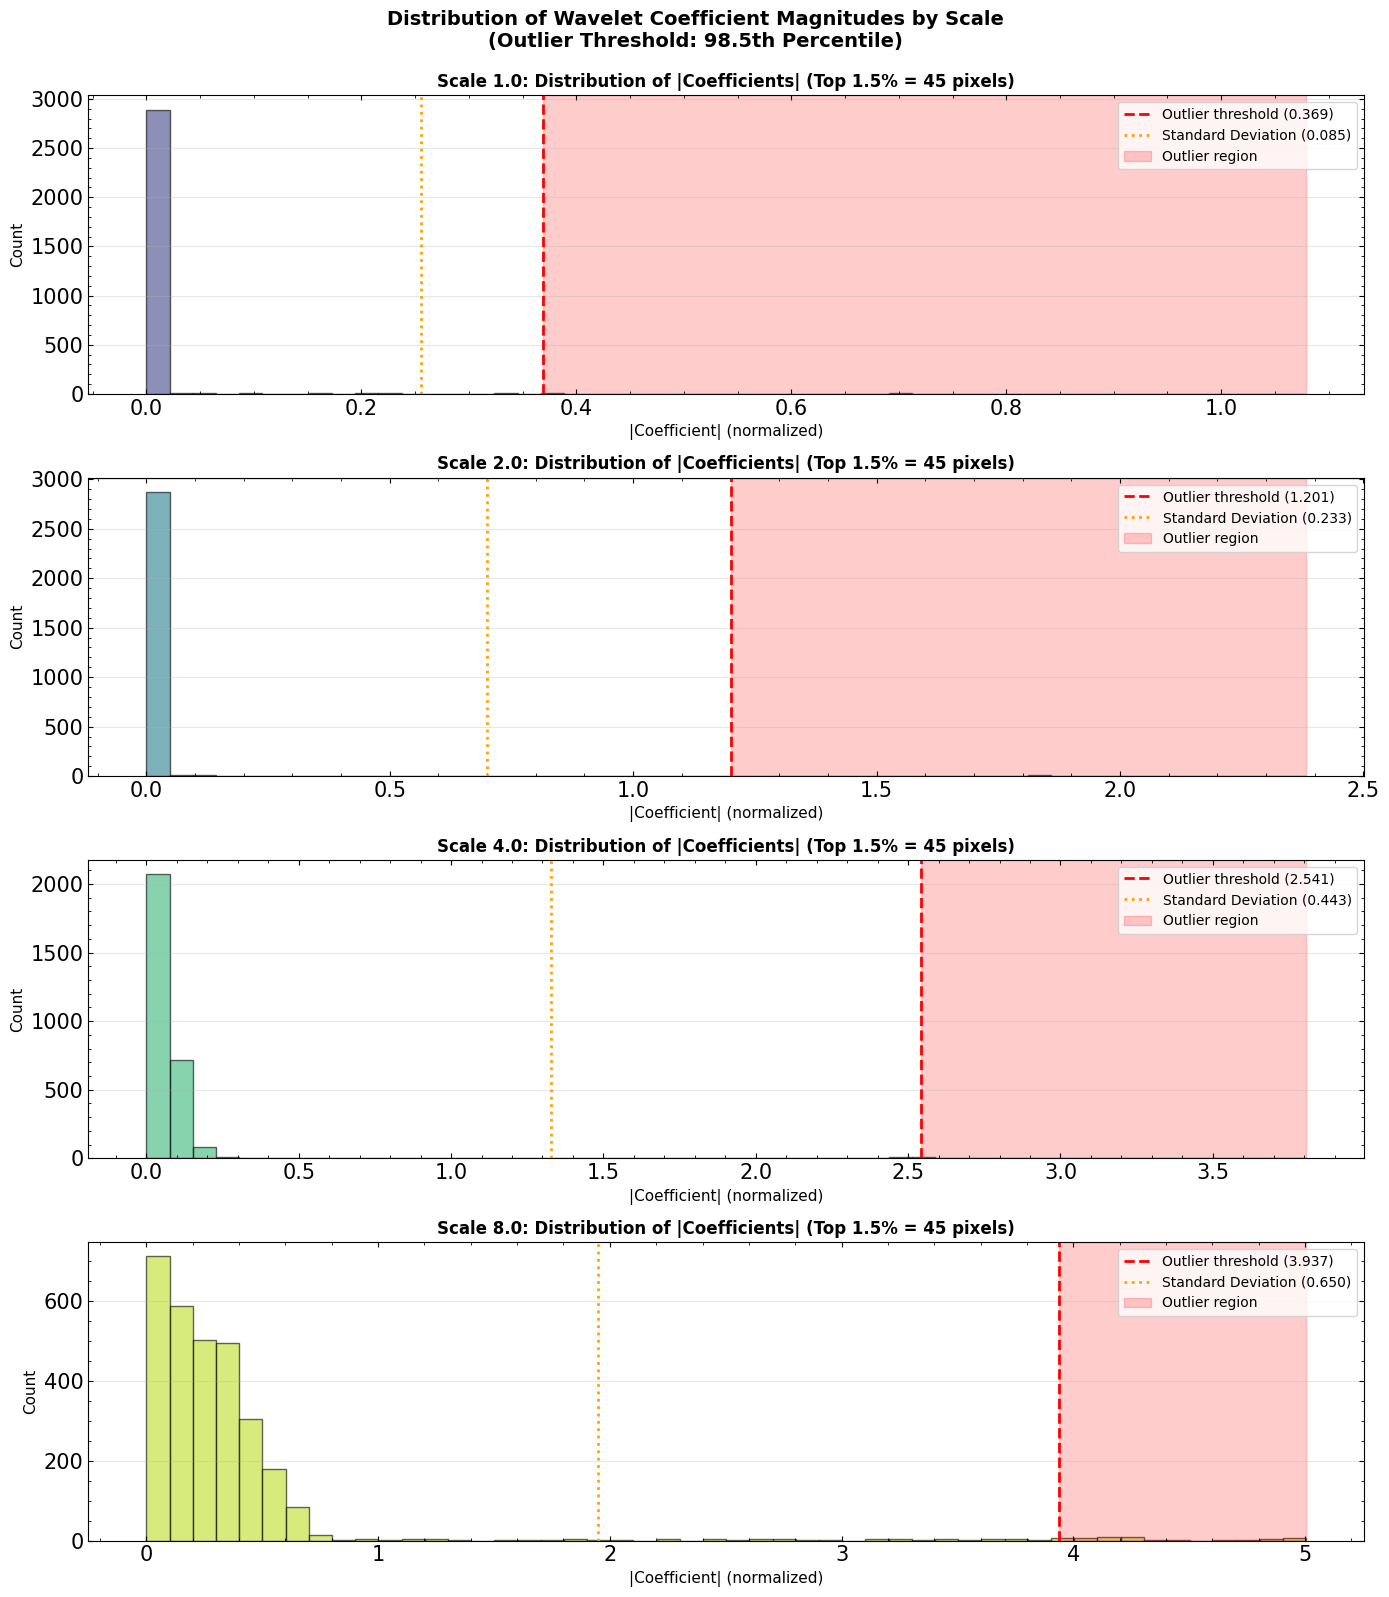

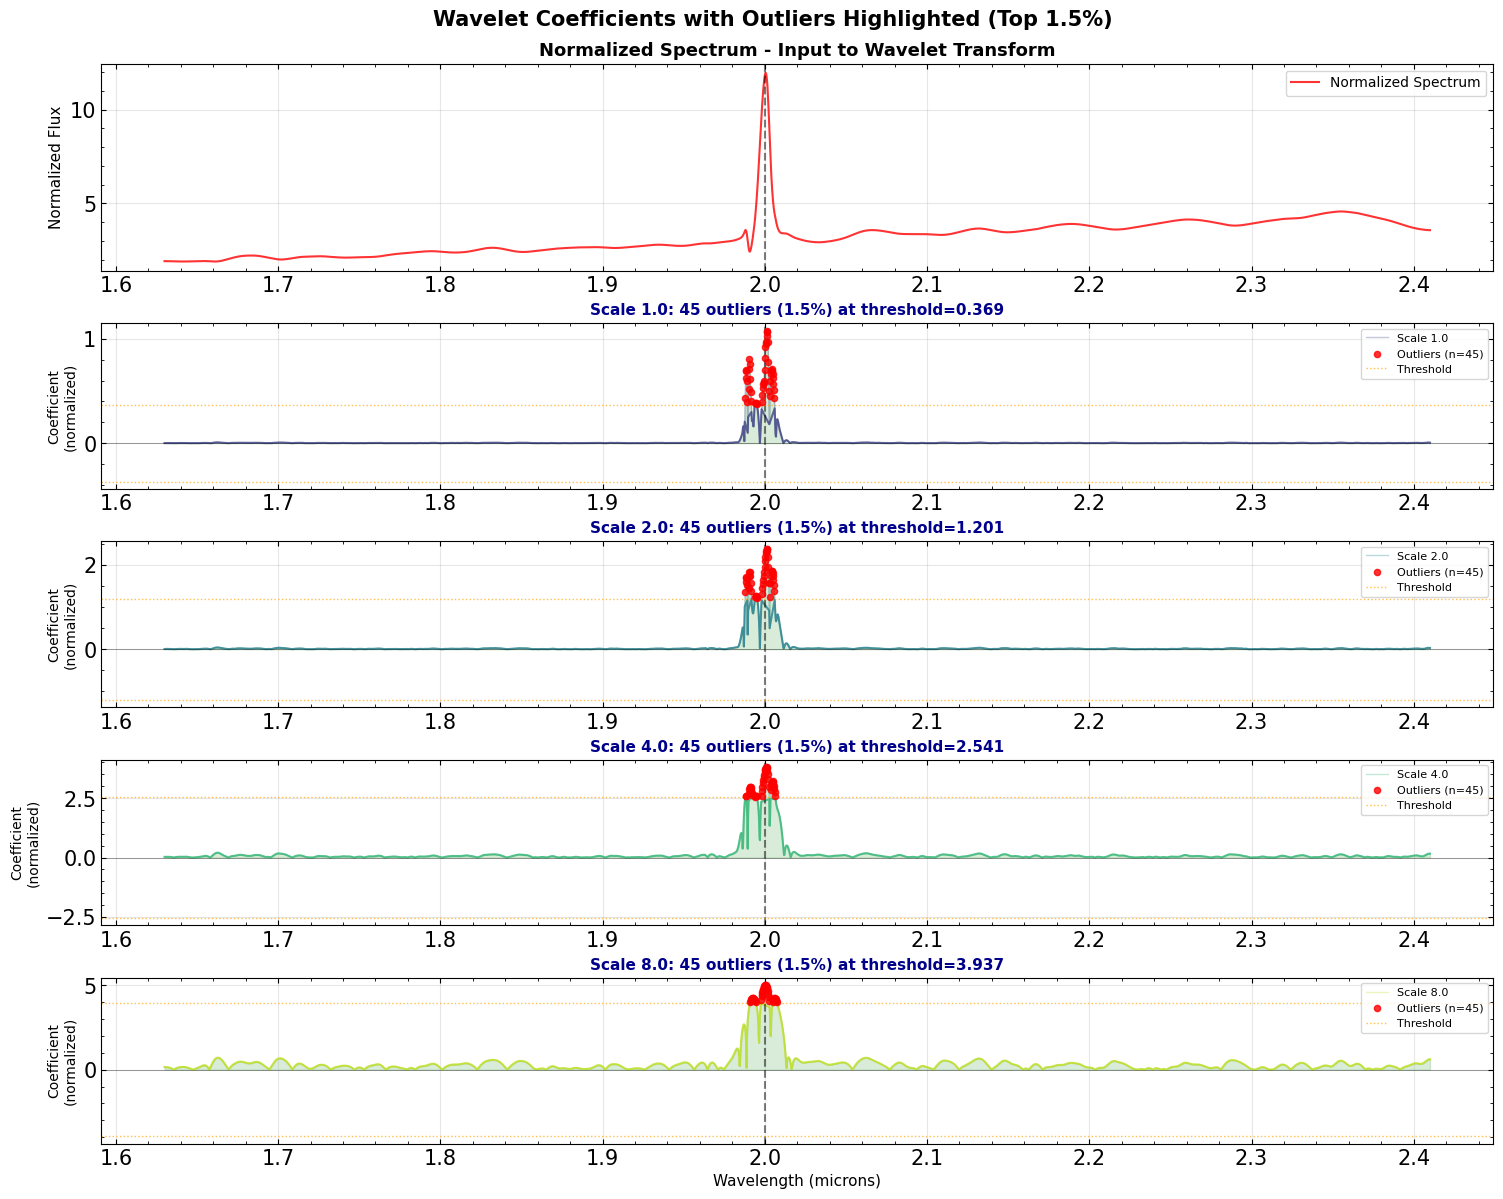

/var/folders/z5/qygyj_xj7dq109c9rzqq2wv40000gn/T/ipykernel_34662/3282028616.py:261: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


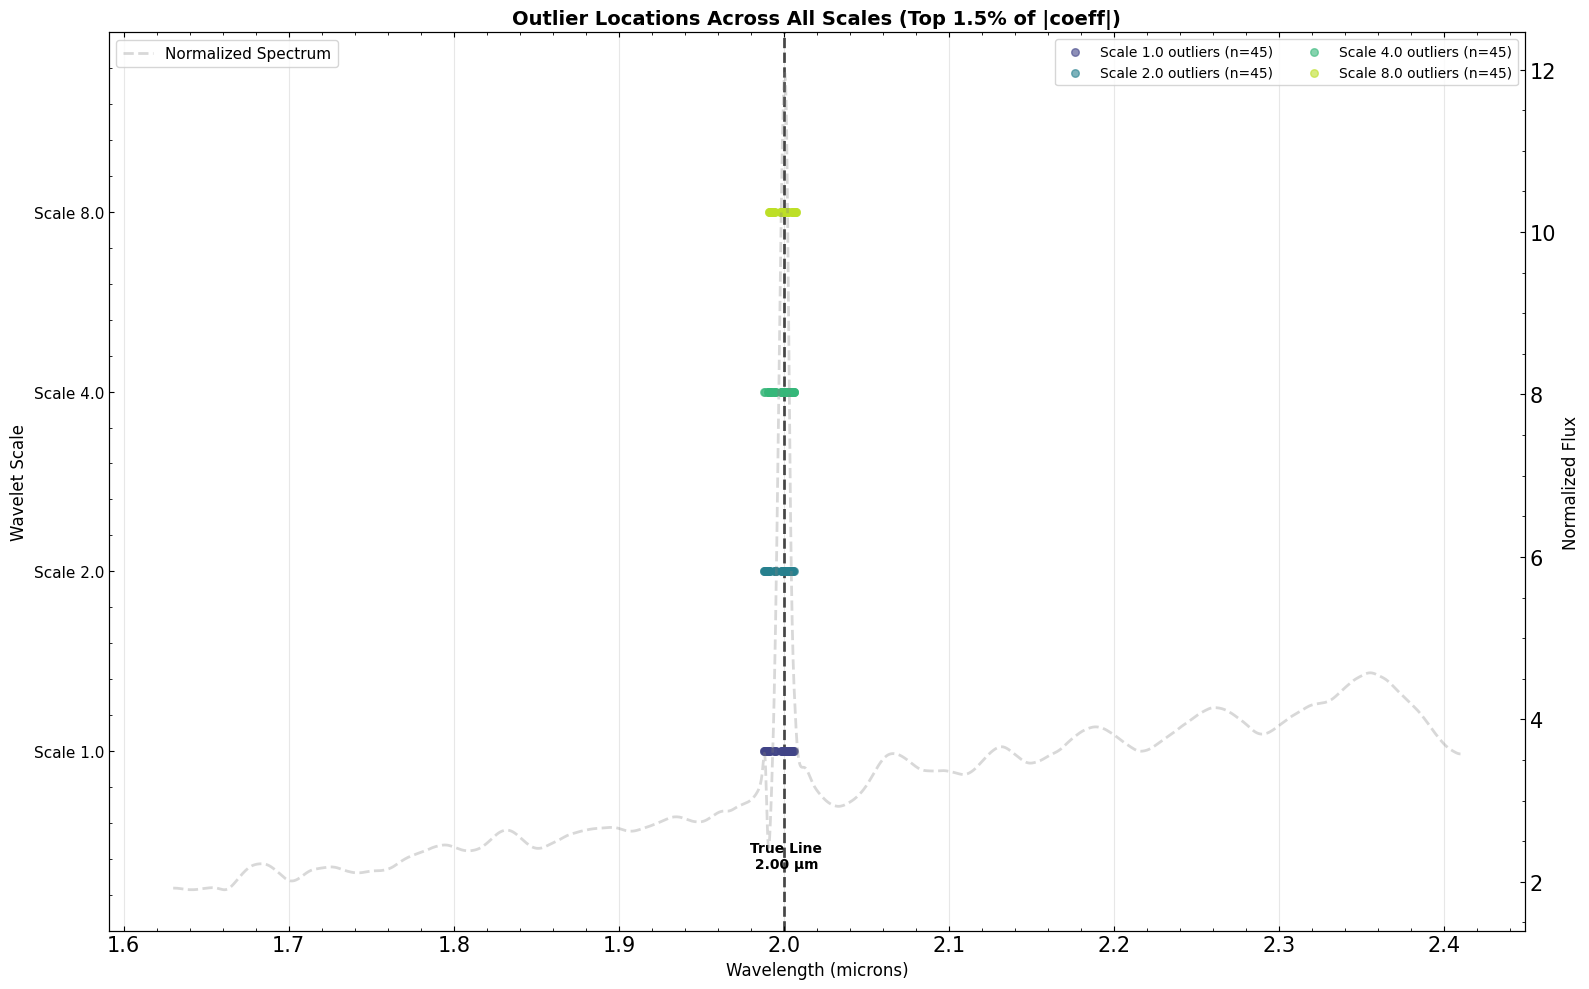


----------------------------------------------------------------------
OUTLIER WAVELENGTH ANALYSIS
----------------------------------------------------------------------

Wavelengths marked as outliers in multiple scales:
(These regions have significant features at multiple scales)
  1.9910 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9913 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9915 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9941 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9944 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9983 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9985 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9988 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9991 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]
  1.9993 μm: 4 scales → [1.0, 2.0, 4.0, 8.0]

Outlier analysis complete!

Interpretation:
  - Outliers = pixels with strongest wavelet response
  - Indicate significant spectral features (emission lines, continuum changes)
  - Different scales capture features at different resolutions
  - Wavelengths marked as

In [11]:
# Outlier Detection in Wavelet Coefficients
# ==========================================

print("=" * 70)
print("WAVELET COEFFICIENT OUTLIER ANALYSIS")
print("=" * 70)

# Define percentile threshold for outliers
outlier_percentile = 98.5  # Top 5% are outliers

print(f"\nOutlier Definition: Top {100 - outlier_percentile}% of |coefficients| for each scale")
print(f"Threshold percentile: {outlier_percentile}%")

# Find outliers for each scale
outlier_indices = {}
outlier_thresholds = {}
outlier_info = []

print(f"\n{'-' * 70}")
print("OUTLIER DETECTION RESULTS")
print(f"{'-' * 70}")

for i, (scale, coeff) in enumerate(zip(cwt_scales, coeffs_by_scale)):
    # Calculate threshold at specified percentile
    threshold = np.percentile(np.abs(coeff), outlier_percentile)
    outlier_thresholds[scale] = threshold

    # Find outlier indices
    outlier_mask = np.abs(coeff) >= threshold
    outlier_idx = np.where(outlier_mask)[0]
    outlier_indices[scale] = outlier_idx

    # Get outlier wavelengths
    outlier_wavelengths = wavelength_recon[outlier_idx]
    outlier_values = coeff[outlier_idx]

    # Statistics
    n_outliers = len(outlier_idx)
    outlier_fraction = n_outliers / len(coeff) * 100
    max_outlier = np.max(np.abs(outlier_values))

    print(f"\nScale {scale}:")
    print(f"  Threshold (|coeff|): {threshold:.4f}")
    print(f"  Number of outliers: {n_outliers} / {len(coeff)} ({outlier_fraction:.1f}%)")
    print(f"  Max |outlier|: {max_outlier:.4f}")
    print(f"  Outlier wavelength range: [{outlier_wavelengths.min():.3f}, {outlier_wavelengths.max():.3f}] μm")

    outlier_info.append(
        {
            "scale": scale,
            "threshold": threshold,
            "n_outliers": n_outliers,
            "outlier_fraction": outlier_fraction,
            "max_outlier": max_outlier,
            "outlier_wavelengths": outlier_wavelengths,
            "outlier_values": outlier_values,
            "outlier_idx": outlier_idx,
        }
    )

print(f"\n{'=' * 70}")

# ------------------------------------------------------------
# VISUALIZATION 1: Outlier Histogram
# ------------------------------------------------------------

fig, axes = plt.subplots(len(cwt_scales), 1, figsize=(14, 4 * len(cwt_scales)), sharex=False)

for i, (info, color) in enumerate(zip(outlier_info, colors)):
    ax = axes[i]

    # Get all absolute coefficients
    abs_coeff = np.abs(coeffs_by_scale[i])
    sigma_coeff = np.std(coeffs_by_scale[i])

    # Create histogram
    n, bins, patches = ax.hist(abs_coeff, bins=50, alpha=0.6, color=color, edgecolor="black")

    # Highlight outliers in red
    threshold = info["threshold"]
    ax.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Outlier threshold ({threshold:.3f})")
    ax.axvline(
        3 * sigma_coeff, color="orange", linestyle=":", linewidth=2, label=f"Standard Deviation ({sigma_coeff:.3f})"
    )

    # Shade outlier region
    ax.axvspan(threshold, abs_coeff.max(), alpha=0.2, color="red", label="Outlier region")

    # Labels
    ax.set_xlabel("|Coefficient| (normalized)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(
        f"Scale {info['scale']}: Distribution of |Coefficients| (Top {100 - outlier_percentile}% = {info['n_outliers']} pixels)",
        fontsize=12,
        fontweight="bold",
    )
    ax.legend(loc="upper right", fontsize=10)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle(
    f"Distribution of Wavelet Coefficient Magnitudes by Scale\n(Outlier Threshold: {outlier_percentile}th Percentile)",
    fontsize=14,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# VISUALIZATION 2: Wavelet Coefficients with Outliers Highlighted
# ------------------------------------------------------------

# Create multi-panel visualization (same as before but with outliers highlighted)
n_scales = len(cwt_scales)
fig = plt.figure(figsize=(16, 4 + 2 * n_scales), constrained_layout=False)

gs = fig.add_gridspec(
    n_scales + 1,
    1,
    height_ratios=[1.0] + [0.8] * n_scales,
    hspace=0.3,
    top=0.95,
    bottom=0.05,
    left=0.08,
    right=0.95,
)

# Panel 0: Normalized spectrum
ax0 = fig.add_subplot(gs[0])
ax0.plot(wavelength_recon, flux_normalized, "r-", linewidth=1.5, alpha=0.8, label="Normalized Spectrum")
ax0.set_ylabel("Normalized Flux", fontsize=11)
ax0.set_title("Normalized Spectrum - Input to Wavelet Transform", fontsize=13, fontweight="bold")
ax0.legend(loc="upper right", fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.axvline(true_line_center, color="k", linestyle="--", alpha=0.5, label="True Line Center")

# Subsequent panels: Wavelet coefficients with outliers highlighted
for i, (info, color) in enumerate(zip(outlier_info, colors)):
    ax = fig.add_subplot(gs[i + 1], sharex=ax0)

    coeff = coeffs_by_scale[i]
    scale = info["scale"]
    threshold = info["threshold"]
    outlier_idx = info["outlier_idx"]

    # Plot all coefficients in faint color
    ax.plot(wavelength_recon, coeff, color=color, linewidth=1.0, alpha=0.3, label=f"Scale {scale}")

    # Plot non-outlier coefficients in normal color
    non_outlier_mask = np.ones(len(coeff), dtype=bool)
    non_outlier_mask[outlier_idx] = False
    ax.plot(wavelength_recon[non_outlier_mask], coeff[non_outlier_mask], color=color, linewidth=1.5, alpha=0.8)

    # Highlight outliers with larger markers and different color
    outlier_wavelengths = wavelength_recon[outlier_idx]
    outlier_values = coeff[outlier_idx]
    ax.scatter(
        outlier_wavelengths,
        outlier_values,
        color="red",
        s=20,
        alpha=0.8,
        zorder=5,
        label=f"Outliers (n={len(outlier_idx)})",
    )

    # Fill positive and negative regions (for non-outliers)
    ax.fill_between(wavelength_recon, 0, coeff, where=(coeff > 0), alpha=0.15, color="green")
    ax.fill_between(wavelength_recon, 0, coeff, where=(coeff < 0), alpha=0.15, color="red")

    # Mark true line position
    ax.axvline(true_line_center, color="k", linestyle="--", alpha=0.5)

    # Add threshold lines
    ax.axhline(threshold, color="orange", linestyle=":", alpha=0.7, linewidth=1)
    ax.axhline(-threshold, color="orange", linestyle=":", alpha=0.7, linewidth=1, label="Threshold")

    # Add zero line
    ax.axhline(0, color="k", linestyle="-", linewidth=0.5, alpha=0.5)

    # Title with statistics
    ax.set_ylabel("Coefficient\n(normalized)", fontsize=10)
    ax.set_title(
        f"Scale {scale}: {len(outlier_idx)} outliers ({info['outlier_fraction']:.1f}%) at threshold={threshold:.3f}",
        fontsize=11,
        fontweight="bold",
        color="darkblue",
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

ax.set_xlabel("Wavelength (microns)", fontsize=11)

fig.suptitle(
    f"Wavelet Coefficients with Outliers Highlighted (Top {100 - outlier_percentile}%)",
    fontsize=15,
    fontweight="bold",
    y=0.995,
)

plt.show()

# ------------------------------------------------------------
# VISUALIZATION 3: Combined View - All Scales with Outlier Locations
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 10))

# Plot normalized spectrum as background
ax2 = ax.twinx()
ax2.plot(wavelength_recon, flux_normalized, "gray", linewidth=2, alpha=0.3, linestyle="--", label="Normalized Spectrum")
ax2.set_ylabel("Normalized Flux", fontsize=12)
ax2.legend(loc="upper left", fontsize=11)

# Plot outlier regions for each scale
y_positions = np.arange(len(cwt_scales))
for i, info in enumerate(outlier_info):
    scale = info["scale"]
    outlier_wavelengths = info["outlier_wavelengths"]
    outlier_values = info["outlier_values"]

    # Create scatter plot for outliers at this scale
    # Use y-position to separate scales visually
    y_pos = y_positions[i]

    # Plot outliers as points
    ax.scatter(
        outlier_wavelengths,
        np.full_like(outlier_wavelengths, y_pos, dtype=float),
        s=30,
        alpha=0.6,
        color=colors[i],
        label=f"Scale {scale} outliers (n={len(outlier_wavelengths)})",
        zorder=5,
    )

# Mark true line center
ax.axvline(true_line_center, color="k", linestyle="--", alpha=0.7, linewidth=2)
ax.text(
    true_line_center,
    -0.5,
    f" True Line\n {true_line_center:.2f} μm",
    fontsize=10,
    ha="center",
    va="top",
    fontweight="bold",
)

# Formatting
ax.set_yticks(y_positions)
ax.set_yticklabels([f"Scale {info['scale']}" for info in outlier_info], fontsize=11)
ax.set_xlabel("Wavelength (microns)", fontsize=12)
ax.set_ylabel("Wavelet Scale", fontsize=12)
ax.set_title(
    f"Outlier Locations Across All Scales (Top {100 - outlier_percentile}% of |coeff|)", fontsize=14, fontweight="bold"
)
ax.set_ylim(-1, len(cwt_scales))
ax.grid(True, alpha=0.3, axis="x")
ax.legend(loc="upper right", fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# SUMMARY: Wavelength ranges with most outliers
# ------------------------------------------------------------

print(f"\n{'-' * 70}")
print("OUTLIER WAVELENGTH ANALYSIS")
print(f"{'-' * 70}")

# Find wavelengths that are outliers in multiple scales
from collections import Counter

all_outlier_wavelengths = []
for info in outlier_info:
    all_outlier_wavelengths.extend(info["outlier_wavelengths"])

# Count how many scales mark each wavelength as outlier
wavelength_outlier_count = Counter(all_outlier_wavelengths)
most_common = wavelength_outlier_count.most_common(10)

print("\nWavelengths marked as outliers in multiple scales:")
print("(These regions have significant features at multiple scales)")
for wavelength, count in most_common:
    if count > 1:
        scales_with_outlier = [info["scale"] for info in outlier_info if wavelength in info["outlier_wavelengths"]]
        print(f"  {wavelength:.4f} μm: {count} scales → {scales_with_outlier}")

print(f"\n{'=' * 70}")
print("Outlier analysis complete!")
print("\nInterpretation:")
print("  - Outliers = pixels with strongest wavelet response")
print("  - Indicate significant spectral features (emission lines, continuum changes)")
print("  - Different scales capture features at different resolutions")
print("  - Wavelengths marked as outliers in multiple scales are especially significant")